# Oil Price WTI Predict by LSTM & TCN model

## Summary

WTI West Texas Intermediate 偶爾稱為德州輕甜原油Texas Light Sweet，它是大宗商品交易中核心的石油基準。

In the issue of predicting oil prices, the ARIMA model in traditional econometric method can already make the model have good accuracy. However, Deep learning can avoids many of the limitations of traditional statistics. In addition, since we only care about the accuracy of the model, not the causal effect between variables, the use of deep learning to make predictions may perform better than tranditional regression models. This project will use deep learning methods TCN and LSTM for crude oil price(WTI) prediction.
    
過去有關時間序列議題上，除了傳統統計以外，使用深度學習方法之學者
常常會使用循環神經網絡（ Recurrent Neural Networks， RNN）來訓練模型，然
而自從 Shaojie Bai, J. Zico Kolter, Vladlen Koltun 於 2018 年發表了〈 An
Empirical Evaluation of Generic Convolutional and Recurrent Networks for Sequence
Modeling, TCN〉這篇文章後， 後續許多研究股價、匯率、期貨等各種議題的總
體實證研究者都開始採用了 TCN 這種深度學習架構來做預測。

**TCN**  Temporal Convolution Network, TCN. Using CNN technology to process time series data. There are three kinds of volume base layers, the first is one-dimensional CNN, which is used to input data, the second is causal convolution, which can handle the sequence problem of time series, and the third is dilated convolution, which can slowly expand the convolution range, increasing the amount of data considered. In addition, CNN has the function of parallel operation, so the training speed is also faster than RNN.
TCN，全名為 Temporal Convolution Network，時間捲積網絡(圖 4)，利用
CNN 處理時間序列資料。裡面有三種卷基層，一是一維 CNN，用來輸入資
料，二個是因果卷積，可以處理時間序列的序列問題，第三個是擴張卷積，可
以慢擴大卷積的範圍，增加考慮的資料量。且 CNN 有平行運算的功能，因此
訓練速度也較 RNN 快。 An Empirical Evaluation of Generic Convolutional and
Recurrent Networks for Sequence Modelin (Shaojie Bai, J. Zico Kolter, Vladlen
Koltun, 2018)提到， TCN 相較於 RNN-LSTM 有更強的記憶力，即過去的資料較
不會散失，且 CNN 有平行運算的功能，因此訓練速度也較 RNN 快

**LSTM** using LSTM 2021/06/31. The long-term and short-term memory model belongs to the recurrent neural network. The RNN LSTM model will consider the value of the previous input to weight the next input before outputting. The LSTM has memory nodes, which are responsible for memorizing or forgetting historical information, so it is suitable for time series data.
長短期記憶模型 LSTM（ Long Short-Term Memory， LSTM） 適合處理和預
測時間序列問題。 LSTM 是由時間循環神經網路（ RNN） (詳見，圖 3)發展而
來， 被描述成智慧型網路單元，可以記憶不定時間長度的數值， 每個區塊之間
有著決定是否記憶的閘門（ Forget gate） 能夠決定 input 是否重要到能被記住及能不能被輸出 output

**Data**
  From January 2014 to June 2021
  Data size : 1868
  
**Dependent variable**
  West Texas Intermediate

**Independent variable**
  1. West Texas Intermediate (sixty days ago)
  2. BRENT Index
  3. Crude oil inventories
  4. MSCI Energy ETF
  5. S&P500
  6. VIX Index

![image](https://user-images.githubusercontent.com/71583821/153644611-fc34555e-73dc-468a-9f2a-e9e655fbdfea.png)


> Model LSTM - Hyper parameter
  
    look_back = 60 days
    
    #-------for networks--------------#
    hidden_feature_dim = 32 
    hidden_layer_num = 2
    classes_num = 1
    dropout = 0.01
    bidirectional = False
    batch_first = True
    
    #-------for training--------------#
    learning_rate = 0.001
    epoch = 1000

**result**
  *Validation RMSE Loss = 0.0492
  ![image](https://user-images.githubusercontent.com/71583821/153667271-561d25f2-d4c6-424b-8bd3-e2ad16929ffc.png)

> Model TCN - Hyper parameter

    #-------for networks--------------#
    look_back_windows = 5 
    kernel_size = 2
    dropout = 0.2

    #-------for training--------------#
    learning_rate = 0.001
    epoch = 1000

**result**
  *Validation RMSE Loss = 0.0475
  ![image](https://user-images.githubusercontent.com/71583821/153667640-9d33e3ee-03ae-40f6-a413-4e7a45c6cf36.png)
  
**RMSE Training Loss**
![image](https://user-images.githubusercontent.com/71583821/157136317-92e12c0b-fd3e-4ea7-9285-854931718111.png)


## 前處理

In [ ]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import torch
import torch.optim as optim
import torch.nn as nn
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline
from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader
import matplotlib.dates as mdates

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Using {} device'.format(device)) 

Using cuda device


In [ ]:
# !gdown --id '1RBb1EQIwCAv1c0J0TBrGvnF4t_oaiHq6' --output orgdata.csv
!gdown --id '1sBOT4cDsl8bLuaz4bZapUbTV0OeijAAc' --output orgdata.csv  #new
# 使用顯卡型號
# K80 < P4 < T4 < P100 <= T4(fp16) < V100
!nvidia-smi

Downloading...
From: https://drive.google.com/uc?id=1sBOT4cDsl8bLuaz4bZapUbTV0OeijAAc
To: /content/orgdata.csv
100% 132k/132k [00:00<00:00, 51.0MB/s]
Thu Jun 10 02:10:57 2021       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 465.27       Driver Version: 460.32.03    CUDA Version: 11.2     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  Tesla P100-PCIE...  Off  | 00000000:00:04.0 Off |                    0 |
| N/A   37C    P0    27W / 250W |      2MiB / 16280MiB |      0%      Default |
|                               |                      |                  N/A |
+-----------------

In [ ]:
import random
import numpy as np

def same_seeds(seed):
    # Python built-in random module
    random.seed(seed)
    # Numpy
    np.random.seed(seed)
    # Torch
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

same_seeds(36544)

In [ ]:
path = 'orgdata.csv'
features = pd.read_csv(path)
features

,Unnamed: 0,日期,標普500,西德州,布蘭特原油,原油庫存,MSCI能源ETF價格,世界能源指數,VIX恐慌指数
0,7257,2013/10/25,1759.77,97.40,105.70,97.849998,25.000000,269.49,13.09
1,7258,2013/10/28,1762.11,98.74,108.29,98.680000,25.040001,269.36,13.31
2,7259,2013/10/29,1771.95,98.29,108.04,98.199997,25.219999,271.72,13.41
3,7260,2013/10/30,1763.31,96.81,108.41,96.769997,25.059999,271.09,13.65
4,7261,2013/10/31,1756.54,96.29,107.53,96.379997,25.000000,269.36,13.75
...,...,...,...,...,...,...,...,...,...
1863,9209,2021/4/20,4134.94,62.61,65.34,62.439999,12.680000,151.47,18.68
1864,9210,2021/4/21,4173.42,61.34,64.02,61.349998,12.870000,153.06,17.50
1865,9211,2021/4/22,4134.98,61.45,65.07,61.430000,12.700000,151.42,18.71
1866,9212,2021/4/23,4180.17,62.18,65.75,62.139999,12.840000,152.06,17.33


In [ ]:
print(np.any(np.isnan(features['原油庫存'])))
print(np.any(np.isnan(features['MSCI能源ETF價格'])))
print(np.any(np.isnan(features['世界能源指數'])))
print(np.any(np.isnan(features['VIX恐慌指数'])))


True
False
False
False


In [ ]:
index = 0
for i in range(len(features['原油庫存'])):
  if np.any(np.isnan(features['原油庫存'].iloc[i])) == True:
    features['原油庫存'].iloc[i] = features['原油庫存'].iloc[i-1]
    index += 1

In [ ]:
print(np.any(np.isnan(features['原油庫存'])))
print(np.any(np.isnan(features['MSCI能源ETF價格'])))
print(np.any(np.isnan(features['世界能源指數'])))
print(np.any(np.isnan(features['VIX恐慌指数'])))


False
False
False
False


In [ ]:
# features.drop(axis=0, columns=[features.columns[0],features.columns[2],features.columns[4],features.columns[6],features.columns[7],features.columns[8]], inplace=True)
features.drop(axis=0, columns=[features.columns[0]], inplace=True)
features.head()

,日期,標普500,西德州,布蘭特原油,原油庫存,MSCI能源ETF價格,世界能源指數,VIX恐慌指数
0,2013/10/25,1759.77,97.40,105.70,97.849998,25.000000,269.49,13.09
1,2013/10/28,1762.11,98.74,108.29,98.680000,25.040001,269.36,13.31
2,2013/10/29,1771.95,98.29,108.04,98.199997,25.219999,271.72,13.41
3,2013/10/30,1763.31,96.81,108.41,96.769997,25.059999,271.09,13.65
4,2013/10/31,1756.54,96.29,107.53,96.379997,25.000000,269.36,13.75


In [ ]:
features.shape

(1868, 8)

In [ ]:
# 時間轉換為datetime格式
date = list(features['日期'])
date_form = []

for i in date:    
    i = i.replace('/','-')
    date_form.append(i)
date_form[:10]

['2013-10-25',
 '2013-10-28',
 '2013-10-29',
 '2013-10-30',
 '2013-10-31',
 '2013-11-1',
 '2013-11-4',
 '2013-11-5',
 '2013-11-6',
 '2013-11-7']

In [ ]:
# date = datetime格式

import datetime
dates = [datetime.datetime.strptime(x, '%Y-%m-%d') for x in date_form]
dates[:5]

[datetime.datetime(2013, 10, 25, 0, 0),
 datetime.datetime(2013, 10, 28, 0, 0),
 datetime.datetime(2013, 10, 29, 0, 0),
 datetime.datetime(2013, 10, 30, 0, 0),
 datetime.datetime(2013, 10, 31, 0, 0)]

In [ ]:
features.set_index("日期")

,標普500,西德州,布蘭特原油,原油庫存,MSCI能源ETF價格,世界能源指數,VIX恐慌指数
日期,,,,,,,
2013/10/25,1759.77,97.40,105.70,97.849998,25.000000,269.49,13.09
2013/10/28,1762.11,98.74,108.29,98.680000,25.040001,269.36,13.31
2013/10/29,1771.95,98.29,108.04,98.199997,25.219999,271.72,13.41
2013/10/30,1763.31,96.81,108.41,96.769997,25.059999,271.09,13.65
2013/10/31,1756.54,96.29,107.53,96.379997,25.000000,269.36,13.75
...,...,...,...,...,...,...,...
2021/4/20,4134.94,62.61,65.34,62.439999,12.680000,151.47,18.68
2021/4/21,4173.42,61.34,64.02,61.349998,12.870000,153.06,17.50
2021/4/22,4134.98,61.45,65.07,61.430000,12.700000,151.42,18.71


## 畫圖觀察相關性

Text(0.5, 1.0, 'VIX Index')

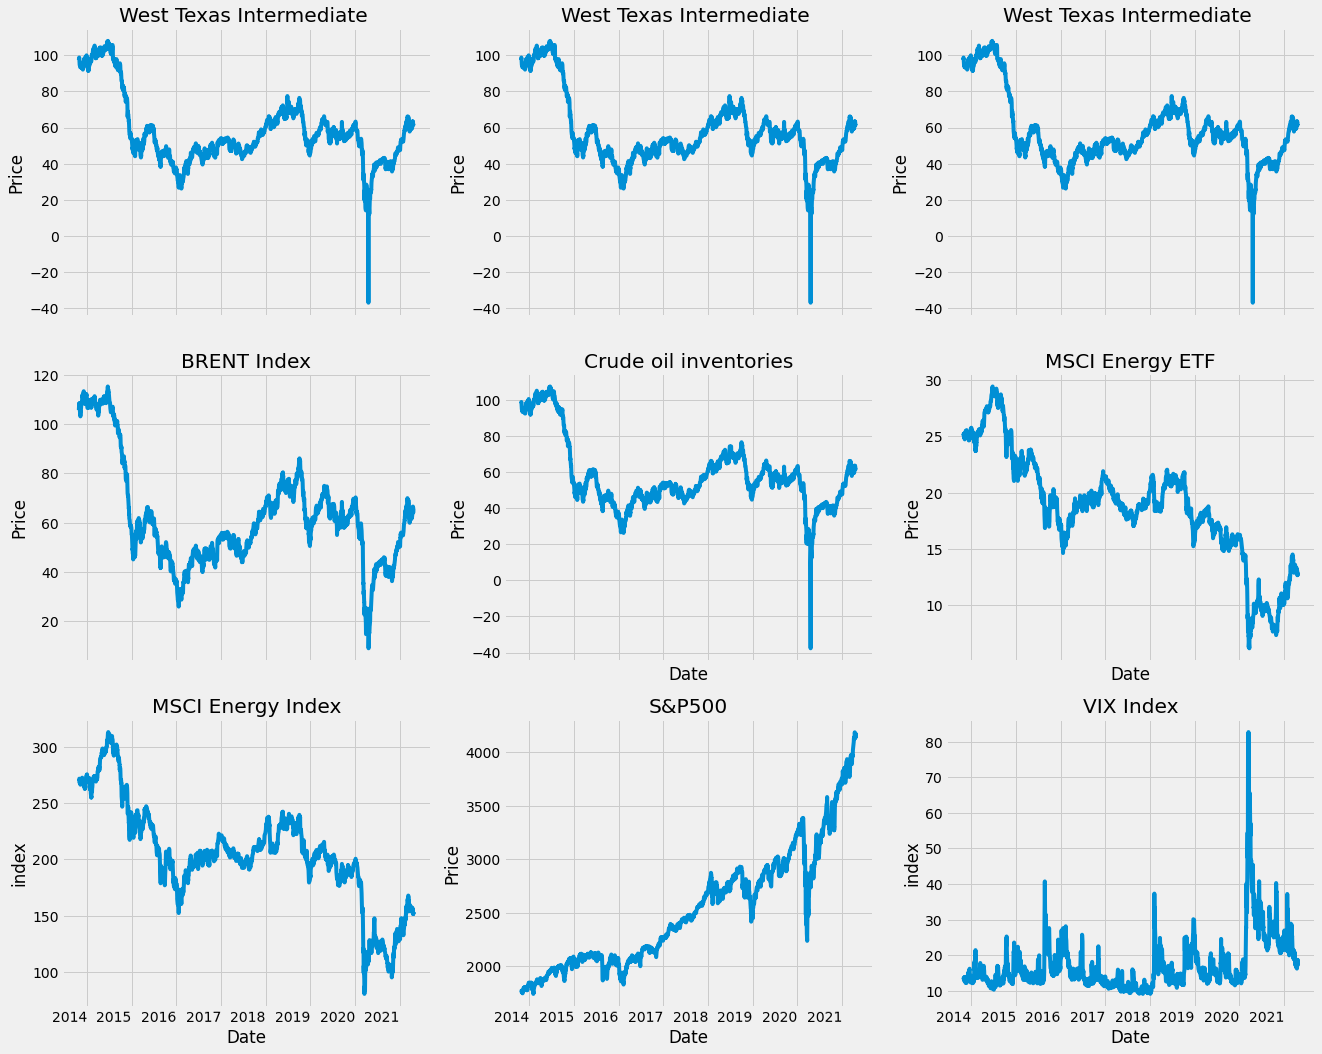

In [ ]:
# 指定風格
plt.style.use('fivethirtyeight')

# 布局
fig, ((ax1, ax2, ax3), (ax4, ax5, ax6), (ax7, ax8, ax9)) = plt.subplots(nrows=3, ncols=3, figsize = (20,20))
fig.autofmt_xdate(rotation = 0.5)

ax1.plot(dates, features['西德州'])
ax1.set_xlabel(''); ax1.set_ylabel('Price'); ax1.set_title('West Texas Intermediate ')


ax2.plot(dates, features['西德州'])
ax2.set_xlabel(''); ax2.set_ylabel('Price'); ax2.set_title('West Texas Intermediate ')

ax3.plot(dates, features['西德州'])
ax3.set_xlabel(''); ax3.set_ylabel('Price'); ax3.set_title('West Texas Intermediate ')

ax4.plot(dates, features['布蘭特原油'])
ax4.set_xlabel(''); ax4.set_ylabel('Price'); ax4.set_title('BRENT Index')    # 布蘭特原油指數

ax5.plot(dates, features['原油庫存'])
ax5.set_xlabel('Date'); ax5.set_ylabel('Price'); ax5.set_title('Crude oil inventories')  # 美國原油庫存

ax6.plot(dates, features['MSCI能源ETF價格'])
ax6.set_xlabel('Date'); ax6.set_ylabel('Price'); ax6.set_title('MSCI Energy ETF')    # MSCI能源ETF價格

ax7.plot(dates, features['世界能源指數'])
ax7.set_xlabel('Date'); ax7.set_ylabel('index'); ax7.set_title('MSCI Energy Index')  # 世界能源指數

ax8.plot(dates, features['標普500'])
ax8.set_xlabel('Date'); ax8.set_ylabel('Price'); ax8.set_title('S&P500')  # S&P500

ax9.plot(dates, features['VIX恐慌指数'])
ax9.set_xlabel('Date'); ax9.set_ylabel('index'); ax9.set_title('VIX Index') # VIX恐慌指数

In [ ]:
features_process = features.iloc[:,1:]
features_process

,標普500,西德州,布蘭特原油,原油庫存,MSCI能源ETF價格,世界能源指數,VIX恐慌指数
0,1759.77,97.40,105.70,97.849998,25.000000,269.49,13.09
1,1762.11,98.74,108.29,98.680000,25.040001,269.36,13.31
2,1771.95,98.29,108.04,98.199997,25.219999,271.72,13.41
3,1763.31,96.81,108.41,96.769997,25.059999,271.09,13.65
4,1756.54,96.29,107.53,96.379997,25.000000,269.36,13.75
...,...,...,...,...,...,...,...
1863,4134.94,62.61,65.34,62.439999,12.680000,151.47,18.68
1864,4173.42,61.34,64.02,61.349998,12.870000,153.06,17.50
1865,4134.98,61.45,65.07,61.430000,12.700000,151.42,18.71
1866,4180.17,62.18,65.75,62.139999,12.840000,152.06,17.33


In [ ]:
df_features = features_process
# df_features = features[['西德州']]
df_features1 = df_features[['西德州']]
df_features2 = df_features[['布蘭特原油']]
df_features3 = df_features[['原油庫存']]
df_features4 = df_features[['標普500']]
df_features5 = df_features[['MSCI能源ETF價格']]
df_features6 = df_features[['世界能源指數']]
df_features7 = df_features[['VIX恐慌指数']]

## 標準化每個features

In [ ]:
from sklearn.preprocessing import MinMaxScaler
df_features1 = df_features1.fillna(method = 'ffill')
df_features2 = df_features2.fillna(method = 'ffill')
df_features3 = df_features3.fillna(method = 'ffill')
df_features4 = df_features4.fillna(method = 'ffill')
df_features5 = df_features5.fillna(method = 'ffill')
df_features6 = df_features6.fillna(method = 'ffill')
df_features7 = df_features7.fillna(method = 'ffill')

scaler = MinMaxScaler(feature_range=(-1, 1))

scaler1 = MinMaxScaler(feature_range=(-1, 1))
df_features['西德州'] = scaler1.fit_transform(df_features['西德州'].values.reshape(-1,1))

scaler_2 = MinMaxScaler(feature_range=(-1, 1))
df_features['布蘭特原油'] = scaler_2.fit_transform(df_features['布蘭特原油'].values.reshape(-1,1))

scaler_3 = MinMaxScaler(feature_range=(-1, 1))
df_features['原油庫存'] = scaler_3.fit_transform(df_features['原油庫存'].values.reshape(-1,1))

scaler_4 = MinMaxScaler(feature_range=(-1, 1))
df_features['標普500'] = scaler_4.fit_transform(df_features['標普500'].values.reshape(-1,1))

scaler_5 = MinMaxScaler(feature_range=(-1, 1))
df_features['MSCI能源ETF價格'] = scaler_5.fit_transform(df_features['MSCI能源ETF價格'].values.reshape(-1,1))

scaler_6 = MinMaxScaler(feature_range=(-1, 1))
df_features['世界能源指數'] = scaler_6.fit_transform(df_features['世界能源指數'].values.reshape(-1,1))

scaler_7 = MinMaxScaler(feature_range=(-1, 1))
df_features['VIX恐慌指数'] = scaler_7.fit_transform(df_features['VIX恐慌指数'].values.reshape(-1,1))

## 設定Hyperparameter

In [ ]:
from torch import optim
import torch as t

#-------for LSTM formula--------------#
look_back = 60 # 用前幾天的資料預測下一天

#-------for networks--------------#
hidden_feature_dim = 32  # LSTM神經元個數
hidden_layer_num = 2 # LSTM的層數
classes_num = 1 # 輸出幾筆資料
dropout = 0.01
bidirectional = False #LSTM通道數 ( True or False )
batch_first = True # 不能動

#-------for training--------------#
learning_rate = 0.001
batch_size = 1 # 不能動
epoch = 1000



## 變數選擇


In [ ]:
# 標普500(1)	西德州(2)	布蘭特原油(3)	原油庫存(4)	MSCI能源ETF價格(5)	世界能源指數(6)	VIX恐慌指数(7) #看要丟掉那些變數
df_features.drop(axis=0, columns=[features.columns[1], features.columns[3], features.columns[4], features.columns[5], features.columns[6], features.columns[7]], inplace=True)
# df_features['西德州']  

## divide Training and validation 

In [ ]:
def load_data(stock, n_timestamp, true, dates):

    data_raw = stock.values # convert to numpy array
    data = [] # for whole test
    
    # create all possible sequences of length look_back
    for index in range(len(data_raw) - n_timestamp): 
        data.append(data_raw[index: index + n_timestamp])
    
    data = np.array(data);
    test_set_size = int(np.round(0.2*data.shape[0]));
    train_set_size = data.shape[0] - (test_set_size);

    train_set_size_list = train_set_size + n_timestamp

    train_dates = dates[:train_set_size]
    test_dates = dates[train_set_size_list:]
    train_true = true[:train_set_size]
    test_true = true[train_set_size_list:]
    
    x_all = data[:,:-1,:]

    x_train = data[:train_set_size,:-1,:]
    y_train = data[:train_set_size,-1,:]
    
    x_test = data[train_set_size:,:-1]
    y_test = data[train_set_size:,-1,:]
    
    return [x_all, x_train, y_train, x_test, y_test, data, train_true, test_true, train_dates, test_dates]


x_all, x_train, y_train, x_test, y_test, data, train_true, test_true, train_dates, test_dates = load_data(df_features, look_back, df_features1, dates)

print('x_all.shape = ',x_all.shape)
print('x_train.shape = ',x_train.shape)
print('y_train.shape = ',y_train.shape)
print('x_test.shape = ',x_test.shape)
print('y_test.shape = ',y_test.shape)
print('train_true.shape = ',train_true.shape)
print('test_true.shape = ',test_true.shape)
print('train_dates.shape = ',len(train_dates))
print('test_dates.shape = ',len(test_dates))

x_all.shape =  (1808, 59, 1)
x_train.shape =  (1446, 59, 1)
y_train.shape =  (1446, 1)
x_test.shape =  (362, 59, 1)
y_test.shape =  (362, 1)
train_true.shape =  (1446, 1)
test_true.shape =  (362, 1)
train_dates.shape =  1446
test_dates.shape =  362


## LSTM層輸入必須三個維度:(seq_len, batch, input_size)沒有batch_first

reference
1. https://zhenglungwu.medium.com/pytorch%E5%AF%A6%E4%BD%9Clstm%E5%9F%B7%E8%A1%8C%E8%A8%8A%E8%99%9F%E9%A0%90%E6%B8%AC-d1d3f17549e7

2. https://clay-atlas.com/blog/2020/05/12/pytorch-lstm-%E7%9A%84%E5%8E%9F%E7%90%86%E8%88%87%E8%BC%B8%E5%85%A5%E8%BC%B8%E5%87%BA%E6%A0%BC%E5%BC%8F%E7%B4%80%E9%8C%84/

3. https://blog.csdn.net/comli_cn/article/details/105275827

4. https://www.itread01.com/content/1549911976.html

5. https://www.kaggle.com/taronzakaryan/predicting-stock-price-using-lstm-model-pytorch


In [ ]:
# 格式轉換 Tensor
x_all, x_train, x_valid, y_train, y_valid = np.array(x_all), np.array(x_train),np.array(x_test),np.array(y_train),np.array(y_test)
x_all, x_train, x_valid, y_train, y_valid = torch.tensor(x_all, dtype = torch.float), torch.tensor(x_train, dtype = torch.float), torch.tensor(x_valid, dtype = torch.float), torch.tensor(y_train, dtype = torch.float), torch.tensor(y_valid, dtype = torch.float)

print(x_train.shape,type(x_train))
print(y_train.shape,type(y_train))
print(x_valid.shape,type(x_valid))
print(y_valid.shape,type(y_valid))
print(x_all.shape,type(x_all))


torch.Size([1446, 59, 1]) <class 'torch.Tensor'>
torch.Size([1446, 1]) <class 'torch.Tensor'>
torch.Size([362, 59, 1]) <class 'torch.Tensor'>
torch.Size([362, 1]) <class 'torch.Tensor'>
torch.Size([1808, 59, 1]) <class 'torch.Tensor'>


In [ ]:
y_train.size(),x_train.size()

(torch.Size([1446, 1]), torch.Size([1446, 59, 1]))

In [ ]:
# feature放進GPU
x_train = x_train.to(device)
y_train = y_train.to(device)
x_valid = x_valid.to(device)
y_valid = y_valid.to(device)

## 建立模型

In [ ]:
class WTI_LSTM(nn.Module):
#建立LSTM class
    # def __init__(self, input_feature_dim, hidden_feature_dim, hidden_layer_num, dropout, bidirectional=bidirectional):
    def __init__(self, input_feature_dim, hidden_feature_dim, hidden_layer_num, batch_first=batch_first):
        super(WTI_LSTM,self).__init__()
        self.input_feature_dim = input_feature_dim
        self.hidden_feature_dim = hidden_feature_dim
        self.hidden_layer_num = hidden_layer_num
        self.batch_first = batch_first
        self.batch_size = batch_size
        self.dropout = dropout
        self.bidirectional = bidirectional

        # self.lstm=nn.LSTM(input_feature_dim, hidden_feature_dim, hidden_layer_num, dropout, bidirectional=bidirectional)   #初始化LSTM 目前為單向(若要雙向則加上bidirectional) 
        self.lstm=nn.LSTM(input_feature_dim, hidden_feature_dim, hidden_layer_num, batch_first=batch_first)
        self.linear1=nn.Linear(hidden_feature_dim,1)# FNN
    
   

       
    def forward(self,x):
        h0 = torch.zeros(self.hidden_layer_num, x.size(0), self.hidden_feature_dim).requires_grad_().to(device)
        c0 = torch.zeros(self.hidden_layer_num, x.size(0), self.hidden_feature_dim).requires_grad_().to(device)
        output,(hn,cn)=self.lstm(x, (h0.detach(), c0.detach()))  
        output=self.linear1(output[:, -1, :])         
        return output,(hn,cn)


## 定義RMSE

In [ ]:
class RMSELoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.mse = nn.MSELoss()
        
    def forward(self,yhat,y):
        return torch.sqrt(self.mse(yhat,y))

## 訓練model的參數定義

In [ ]:
input_feature_dim = x_train.shape[2] # 變數有幾個

model = WTI_LSTM(input_feature_dim, hidden_feature_dim, hidden_layer_num, batch_first=batch_first).to(device)
#-------for optimizer and evaluation--------------#
opt = optim.Adam(model.parameters(), lr=learning_rate)
loss_func = RMSELoss()

In [ ]:
def train(x_train, y_train, hist):
    model.train()
    # n_timestamp = look_back-1
    pred,(hn,cn) = model(x_train)

    loss = loss_func(pred, y_train.to(device))

    hist[t] = loss.item()
    # Zero out gradient, else they will accumulate between epochs
    opt.zero_grad()
    # Backward pass
    loss.backward()
    # Update parameters
    opt.step()
    return pred, loss, hist[t]

In [ ]:
def test(x_test, y_test, hist_val):
    model.eval()  # 關閉batchnormaliztion和dropout
    # n_timestamp = look_back-1
    predict_val,(hn,cn) = model(x_test)

    loss_val = loss_func(predict_val , y_test)
    hist_val[t] = loss.item()

    return predict_val, loss_val, hist_val[t]

In [ ]:
# Train model
#####################  0.1651

hist = np.zeros(epoch)
hist_val = np.zeros(epoch)

# Number of steps to unroll


t = 0
for t in range(epoch):
  pred, loss, hist[t] = train(x_train, y_train, hist)
  predict_val, loss_val, hist_val[t] = test(x_valid, y_valid, hist_val)
  t += 1
  if (t) % 10 == 0:
    print(f'epoch:{t}  -------  loss:{loss.item():.4f}  -------  valid_loss:{loss_val.item():.4f}')  

model.train(False)

epoch:10  -------  loss:0.2705  -------  valid_loss:0.2083
epoch:20  -------  loss:0.2488  -------  valid_loss:0.3097
epoch:30  -------  loss:0.2298  -------  valid_loss:0.2427
epoch:40  -------  loss:0.2013  -------  valid_loss:0.2415
epoch:50  -------  loss:0.0785  -------  valid_loss:0.1484
epoch:60  -------  loss:0.0638  -------  valid_loss:0.1392
epoch:70  -------  loss:0.0539  -------  valid_loss:0.1147
epoch:80  -------  loss:0.0483  -------  valid_loss:0.1043
epoch:90  -------  loss:0.0424  -------  valid_loss:0.0879
epoch:100  -------  loss:0.0381  -------  valid_loss:0.0807
epoch:110  -------  loss:0.0350  -------  valid_loss:0.0761
epoch:120  -------  loss:0.0325  -------  valid_loss:0.0710
epoch:130  -------  loss:0.0301  -------  valid_loss:0.0659
epoch:140  -------  loss:0.0286  -------  valid_loss:0.0619
epoch:150  -------  loss:0.0280  -------  valid_loss:0.0603
epoch:160  -------  loss:0.0275  -------  valid_loss:0.0597
epoch:170  -------  loss:0.0270  -------  valid_l

WTI_LSTM(
  (lstm): LSTM(1, 32, num_layers=2, batch_first=True)
  (linear1): Linear(in_features=32, out_features=1, bias=True)
)

In [ ]:

pred,(hn,cn) = model(x_train)
pred

tensor([[0.8064],
        [0.8255],
        [0.8437],
        ...,
        [0.2579],
        [0.2699],
        [0.2834]], device='cuda:0', grad_fn=<AddmmBackward>)

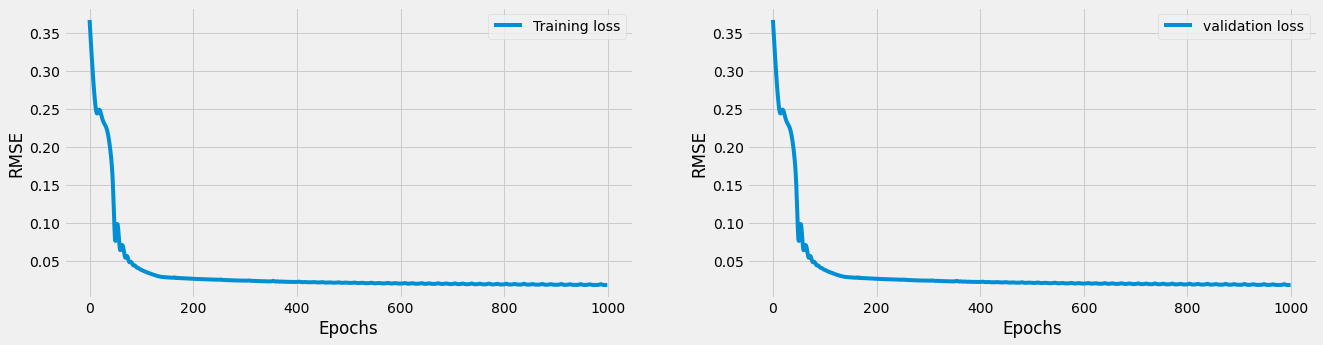

In [ ]:
plt.subplots(figsize=(20,5))

plt.subplot(1,2,1)
plt.ylabel("RMSE")
plt.xlabel("Epochs")
plt.plot(hist, label="Training loss")
plt.legend()

plt.subplot(1,2,2)
plt.ylabel("RMSE")
plt.xlabel("Epochs")
plt.plot(hist_val, label="validation loss")
plt.legend()

## inference

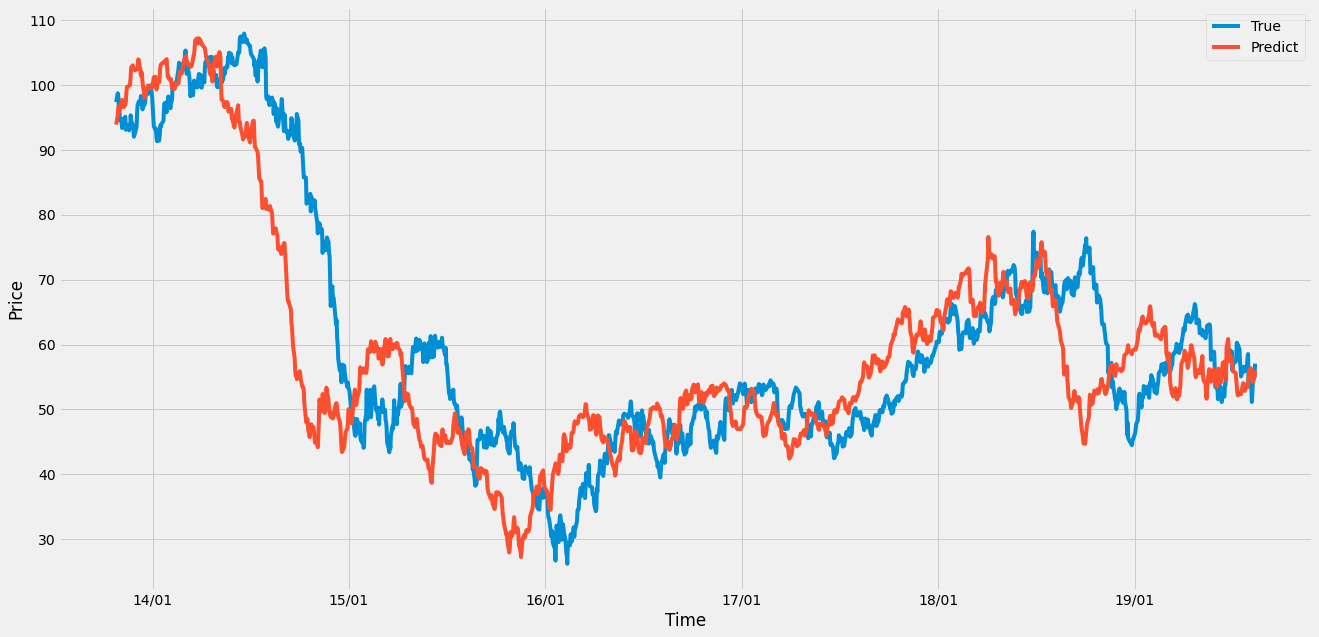

In [ ]:
# Training data 訓練結果
plt.subplots(figsize=(20,10))
pred,(hn,cn) = model(x_train)
plt.ylabel("Price")
plt.xlabel("Time")
pred = scaler1.inverse_transform(pred.detach().cpu().numpy())
pred_list = [] #pred to list
for i in pred:
  pred_list.append(i[0])

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%y/%m'))
plt.plot(train_dates,train_true, label="True")
plt.plot(train_dates,pred_list, label="Predict")

plt.legend()

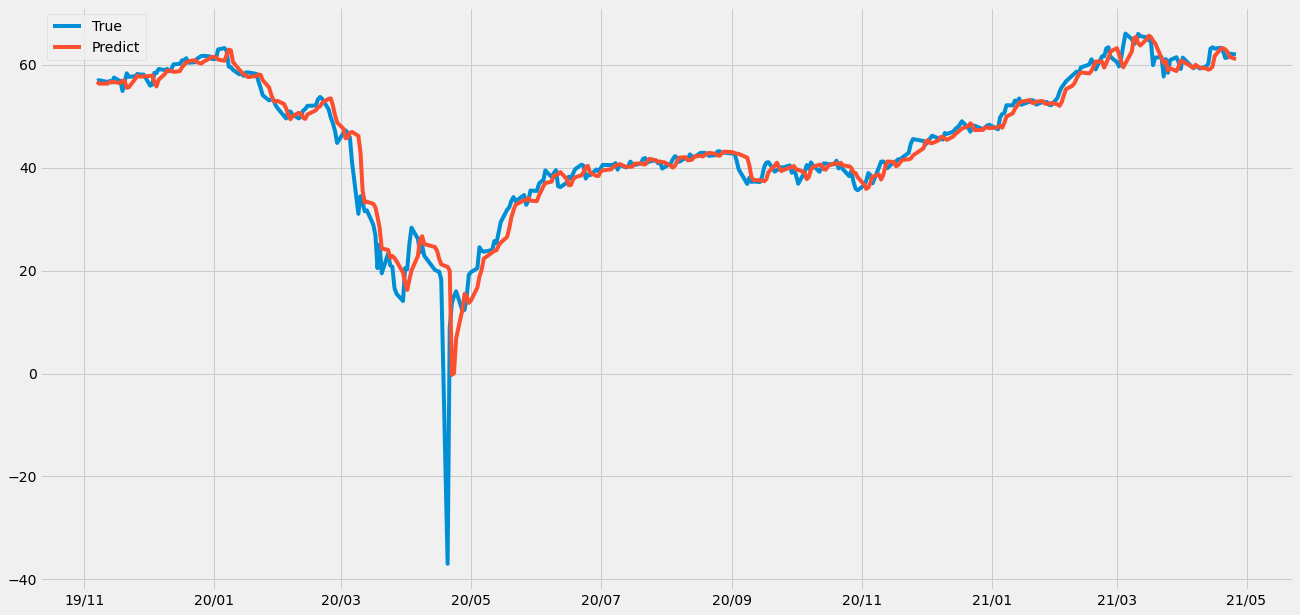

In [ ]:
# Testing data訓練結果
plt.subplots(figsize=(20,10))
pred,(hn,cn) = model(x_valid)
pred = scaler1.inverse_transform(pred.detach().cpu().numpy())
pred_list = [] #pred to list
for i in pred:
  pred_list.append(i[0])

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%y/%m'))
plt.plot(test_dates, test_true, label="True")
plt.plot(test_dates, pred_list, label="Predict")

plt.legend()

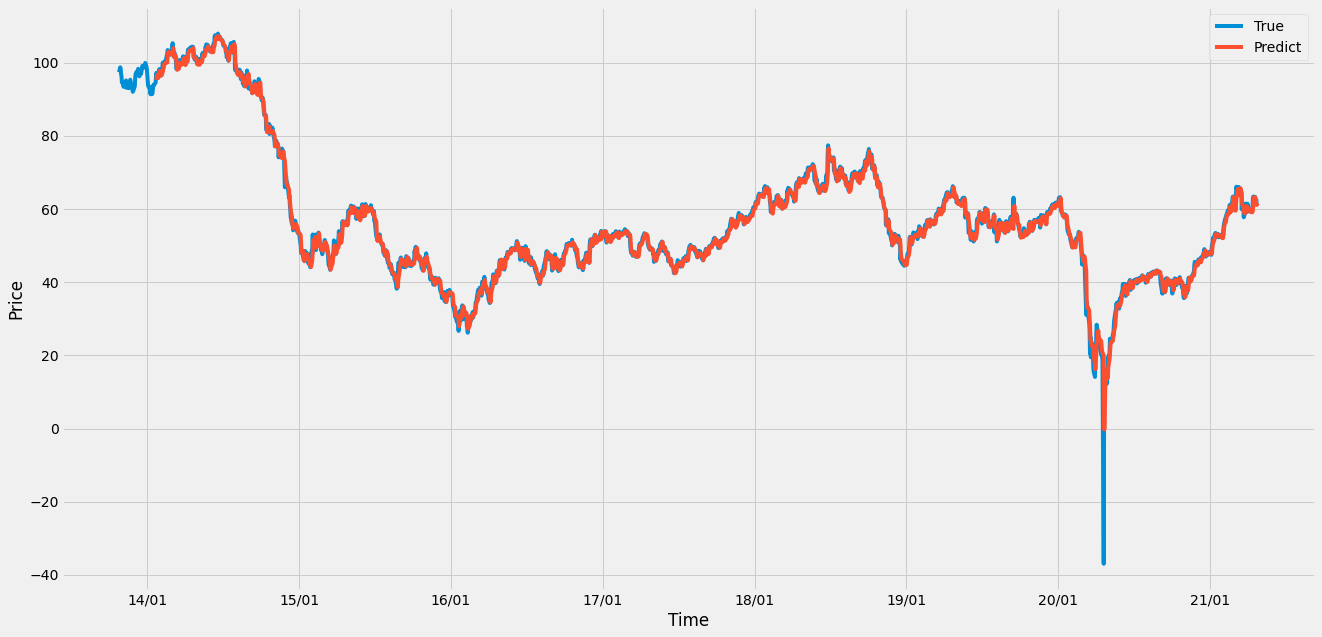

In [ ]:
# 全期訓練結果

plt.subplots(figsize=(20,10))
data = torch.tensor(data, dtype = torch.float)

pred,(hn,cn) = model(data.to(device))
plt.ylabel("Price")
plt.xlabel("Time")
pred = scaler1.inverse_transform(pred.detach().cpu().numpy())

pred_list = [] #pred to list
for i in pred:
  pred_list.append(i[0])

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%y/%m'))

plt.plot(dates, df_features1, label="True")

plt.plot(dates[look_back:], pred_list,  label="Predict")

plt.legend()

In [ ]:
data.shape

torch.Size([1808, 60, 1])

# --- TCN model ---

## 前處理

In [ ]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import torch
import torch.optim as optim
import torch.nn as nn
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline
from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader
import matplotlib.dates as mdates
from sklearn.preprocessing import MinMaxScaler

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Using {} device'.format(device)) 

Using cuda device


In [ ]:
!gdown --id '11r8ZxjlDFy3I0VlT5JVYPxWq7sRYMnSl' --output orgdata.csv

!ls 
# 使用顯卡型號
# K80 < P4 < T4 < P100 <= T4(fp16) < V100
!nvidia-smi

Downloading...
From: https://drive.google.com/uc?id=11r8ZxjlDFy3I0VlT5JVYPxWq7sRYMnSl
To: /content/orgdata.csv
100% 132k/132k [00:00<00:00, 49.7MB/s]
orgdata.csv  sample_data
Mon Nov  8 02:34:12 2021       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 495.44       Driver Version: 460.32.03    CUDA Version: 11.2     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  Tesla P100-PCIE...  Off  | 00000000:00:04.0 Off |                    0 |
| N/A   35C    P0    26W / 250W |      2MiB / 16280MiB |      0%      Default |
|                               |                      |                 

In [ ]:
import random
import numpy as np

def same_seeds(seed):
    # Python built-in random module
    random.seed(seed)
    # Numpy
    np.random.seed(seed)
    # Torch
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

same_seeds(36544)

In [ ]:
path = 'orgdata.csv'
features = pd.read_csv(path)
features

,Unnamed: 0,日期,標普500,西德州,布蘭特原油,原油庫存,MSCI能源ETF價格,世界能源指數,VIX恐慌指数
0,7257,2013/10/25,1759.77,97.40,105.70,97.849998,25.000000,269.49,13.09
1,7258,2013/10/28,1762.11,98.74,108.29,98.680000,25.040001,269.36,13.31
2,7259,2013/10/29,1771.95,98.29,108.04,98.199997,25.219999,271.72,13.41
3,7260,2013/10/30,1763.31,96.81,108.41,96.769997,25.059999,271.09,13.65
4,7261,2013/10/31,1756.54,96.29,107.53,96.379997,25.000000,269.36,13.75
...,...,...,...,...,...,...,...,...,...
1863,9209,2021/4/20,4134.94,62.61,65.34,62.439999,12.680000,151.47,18.68
1864,9210,2021/4/21,4173.42,61.34,64.02,61.349998,12.870000,153.06,17.50
1865,9211,2021/4/22,4134.98,61.45,65.07,61.430000,12.700000,151.42,18.71
1866,9212,2021/4/23,4180.17,62.18,65.75,62.139999,12.840000,152.06,17.33


## 檢查是否有nan 並解決

In [ ]:
print(np.any(np.isnan(features['原油庫存'])))
print(np.any(np.isnan(features['MSCI能源ETF價格'])))
print(np.any(np.isnan(features['世界能源指數'])))
print(np.any(np.isnan(features['VIX恐慌指数'])))

True
False
False
False


In [ ]:
index = 0
for i in range(len(features['原油庫存'])):
  if np.any(np.isnan(features['原油庫存'].iloc[i])) == True:
    features['原油庫存'].iloc[i] = features['原油庫存'].iloc[i-1]
    index += 1

In [ ]:
print(np.any(np.isnan(features['原油庫存'])))
print(np.any(np.isnan(features['MSCI能源ETF價格'])))
print(np.any(np.isnan(features['世界能源指數'])))
print(np.any(np.isnan(features['VIX恐慌指数'])))


False
False
False
False


In [ ]:
# features.drop(axis=0, columns=[features.columns[0],features.columns[2],features.columns[4],features.columns[6],features.columns[7],features.columns[8]], inplace=True)
features.drop(axis=0, columns=[features.columns[0]], inplace=True)
features

,日期,標普500,西德州,布蘭特原油,原油庫存,MSCI能源ETF價格,世界能源指數,VIX恐慌指数
0,2013/10/25,1759.77,97.40,105.70,97.849998,25.000000,269.49,13.09
1,2013/10/28,1762.11,98.74,108.29,98.680000,25.040001,269.36,13.31
2,2013/10/29,1771.95,98.29,108.04,98.199997,25.219999,271.72,13.41
3,2013/10/30,1763.31,96.81,108.41,96.769997,25.059999,271.09,13.65
4,2013/10/31,1756.54,96.29,107.53,96.379997,25.000000,269.36,13.75
...,...,...,...,...,...,...,...,...
1863,2021/4/20,4134.94,62.61,65.34,62.439999,12.680000,151.47,18.68
1864,2021/4/21,4173.42,61.34,64.02,61.349998,12.870000,153.06,17.50
1865,2021/4/22,4134.98,61.45,65.07,61.430000,12.700000,151.42,18.71
1866,2021/4/23,4180.17,62.18,65.75,62.139999,12.840000,152.06,17.33


## 時間轉換為datetime格式

In [ ]:

date = list(features['日期'])
date_form = []

for i in date:    
    i = i.replace('/','-')
    date_form.append(i)
date_form[:10]

['2013-10-25',
 '2013-10-28',
 '2013-10-29',
 '2013-10-30',
 '2013-10-31',
 '2013-11-1',
 '2013-11-4',
 '2013-11-5',
 '2013-11-6',
 '2013-11-7']

In [ ]:
# date = datetime格式

import datetime
dates = [datetime.datetime.strptime(x, '%Y-%m-%d') for x in date_form]
dates[:5]

[datetime.datetime(2013, 10, 25, 0, 0),
 datetime.datetime(2013, 10, 28, 0, 0),
 datetime.datetime(2013, 10, 29, 0, 0),
 datetime.datetime(2013, 10, 30, 0, 0),
 datetime.datetime(2013, 10, 31, 0, 0)]

In [ ]:
features.set_index("日期")

,標普500,西德州,布蘭特原油,原油庫存,MSCI能源ETF價格,世界能源指數,VIX恐慌指数
日期,,,,,,,
2013/10/25,1759.77,97.40,105.70,97.849998,25.000000,269.49,13.09
2013/10/28,1762.11,98.74,108.29,98.680000,25.040001,269.36,13.31
2013/10/29,1771.95,98.29,108.04,98.199997,25.219999,271.72,13.41
2013/10/30,1763.31,96.81,108.41,96.769997,25.059999,271.09,13.65
2013/10/31,1756.54,96.29,107.53,96.379997,25.000000,269.36,13.75
...,...,...,...,...,...,...,...
2021/4/20,4134.94,62.61,65.34,62.439999,12.680000,151.47,18.68
2021/4/21,4173.42,61.34,64.02,61.349998,12.870000,153.06,17.50
2021/4/22,4134.98,61.45,65.07,61.430000,12.700000,151.42,18.71


Text(0.5, 1.0, 'VIX Index')

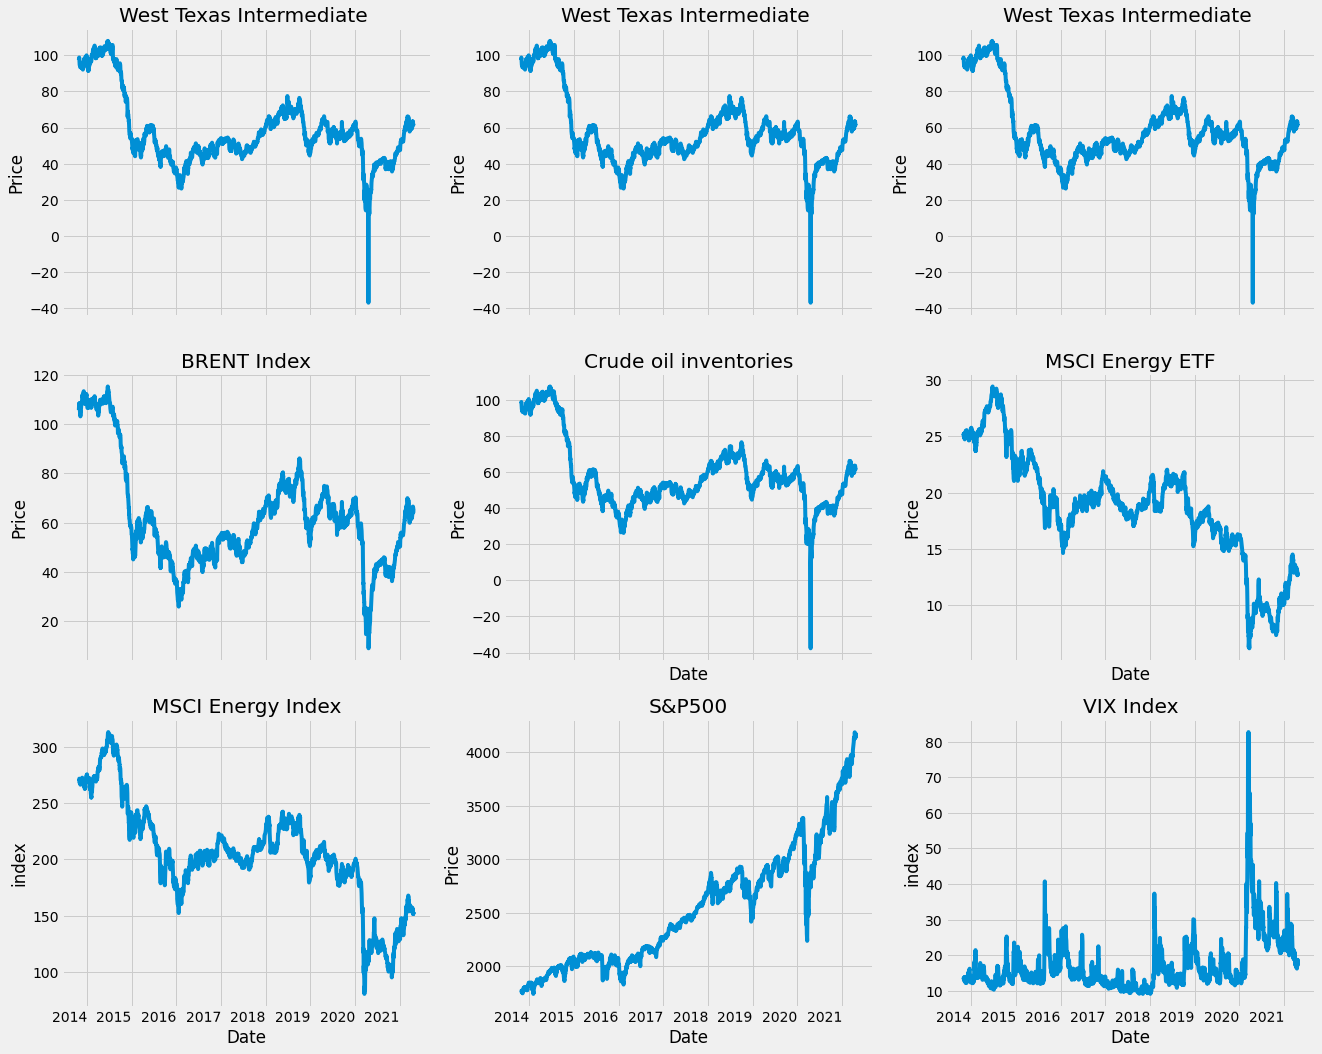

In [ ]:
# 指定風格
plt.style.use('fivethirtyeight')

# 布局
fig, ((ax1, ax2, ax3), (ax4, ax5, ax6), (ax7, ax8, ax9)) = plt.subplots(nrows=3, ncols=3, figsize = (20,20))
fig.autofmt_xdate(rotation = 0.5)

ax1.plot(dates, features['西德州'])
ax1.set_xlabel(''); ax1.set_ylabel('Price'); ax1.set_title('West Texas Intermediate ')


ax2.plot(dates, features['西德州'])
ax2.set_xlabel(''); ax2.set_ylabel('Price'); ax2.set_title('West Texas Intermediate ')

ax3.plot(dates, features['西德州'])
ax3.set_xlabel(''); ax3.set_ylabel('Price'); ax3.set_title('West Texas Intermediate ')

ax4.plot(dates, features['布蘭特原油'])
ax4.set_xlabel(''); ax4.set_ylabel('Price'); ax4.set_title('BRENT Index')    # 布蘭特原油指數


ax5.plot(dates, features['原油庫存'])
ax5.set_xlabel('Date'); ax5.set_ylabel('Price'); ax5.set_title('Crude oil inventories')  # 美國原油庫存

ax6.plot(dates, features['MSCI能源ETF價格'])
ax6.set_xlabel('Date'); ax6.set_ylabel('Price'); ax6.set_title('MSCI Energy ETF')    # MSCI能源ETF價格

ax7.plot(dates, features['世界能源指數'])
ax7.set_xlabel('Date'); ax7.set_ylabel('index'); ax7.set_title('MSCI Energy Index')  # 世界能源指數

ax8.plot(dates, features['標普500'])
ax8.set_xlabel('Date'); ax8.set_ylabel('Price'); ax8.set_title('S&P500')  # S&P500
 
ax9.plot(dates, features['VIX恐慌指数'])
ax9.set_xlabel('Date'); ax9.set_ylabel('index'); ax9.set_title('VIX Index') # VIX恐慌指数
 
# plt.tight_layout(pad=2)

In [ ]:
features_process = features.iloc[:,1:]
features_process


,標普500,西德州,布蘭特原油,原油庫存,MSCI能源ETF價格,世界能源指數,VIX恐慌指数
0,1759.77,97.40,105.70,97.849998,25.000000,269.49,13.09
1,1762.11,98.74,108.29,98.680000,25.040001,269.36,13.31
2,1771.95,98.29,108.04,98.199997,25.219999,271.72,13.41
3,1763.31,96.81,108.41,96.769997,25.059999,271.09,13.65
4,1756.54,96.29,107.53,96.379997,25.000000,269.36,13.75
...,...,...,...,...,...,...,...
1863,4134.94,62.61,65.34,62.439999,12.680000,151.47,18.68
1864,4173.42,61.34,64.02,61.349998,12.870000,153.06,17.50
1865,4134.98,61.45,65.07,61.430000,12.700000,151.42,18.71
1866,4180.17,62.18,65.75,62.139999,12.840000,152.06,17.33


In [ ]:
df_features = features_process
df_features1 = df_features[['西德州']]
df_features2 = df_features[['布蘭特原油']]
df_features3 = df_features[['原油庫存']]
df_features4 = df_features[['標普500']]
df_features5 = df_features[['MSCI能源ETF價格']]
df_features6 = df_features[['世界能源指數']]
df_features7 = df_features[['VIX恐慌指数']]

## 標準化每個features

In [ ]:
from sklearn.preprocessing import MinMaxScaler

df_features1 = df_features1.fillna(method = 'ffill')
df_features2 = df_features2.fillna(method = 'ffill')
df_features3 = df_features3.fillna(method = 'ffill')
df_features4 = df_features4.fillna(method = 'ffill')
df_features5 = df_features5.fillna(method = 'ffill')
df_features6 = df_features6.fillna(method = 'ffill')
df_features7 = df_features7.fillna(method = 'ffill')

scaler = MinMaxScaler(feature_range=(-1, 1))

scaler1 = MinMaxScaler(feature_range=(-1, 1))
df_features['西德州'] = scaler1.fit_transform(df_features['西德州'].values.reshape(-1,1))

scaler_2 = MinMaxScaler(feature_range=(-1, 1))
df_features['布蘭特原油'] = scaler_2.fit_transform(df_features['布蘭特原油'].values.reshape(-1,1))

scaler_3 = MinMaxScaler(feature_range=(-1, 1))
df_features['原油庫存'] = scaler_3.fit_transform(df_features['原油庫存'].values.reshape(-1,1))

scaler_4 = MinMaxScaler(feature_range=(-1, 1))
df_features['標普500'] = scaler_4.fit_transform(df_features['標普500'].values.reshape(-1,1))

scaler_5 = MinMaxScaler(feature_range=(-1, 1))
df_features['MSCI能源ETF價格'] = scaler_5.fit_transform(df_features['MSCI能源ETF價格'].values.reshape(-1,1))

scaler_6 = MinMaxScaler(feature_range=(-1, 1))
df_features['世界能源指數'] = scaler_6.fit_transform(df_features['世界能源指數'].values.reshape(-1,1))

scaler_7 = MinMaxScaler(feature_range=(-1, 1))
df_features['VIX恐慌指数'] = scaler_7.fit_transform(df_features['VIX恐慌指数'].values.reshape(-1,1))

## 變數選擇


In [ ]:
  # 標普500(1)	西德州(2)	布蘭特原油(3)	原油庫存(4)	MSCI能源ETF價格(5)	世界能源指數(6)	VIX恐慌指数(7)

# df_features.drop(axis=0, columns=[features.columns[1], features.columns[3], features.columns[4], features.columns[5], features.columns[6], features.columns[7]], inplace=True) 
# df_features.drop(axis=0, columns=[features.columns[3], features.columns[6]], inplace=True)

## divide Training and validation 


Input shape

3D tensor with shape (batch_size, timesteps, input_dim).
同LSTM的batch_first

timesteps can be None. This can be useful if each sequence is of a different length: Multiple Length Sequence Example

## 設定Hyperparameter

In [ ]:
from torch import optim
import torch as t

#-------for LSTM formula--------------#
look_back_windows = 5 # 用前幾天的資料預測下一天 同look_back

#-------for networks--------------#
kernel_size = 2
dropout = 0.2

#-------for training--------------#
learning_rate = 0.001
epoch = 1000

In [ ]:
def load_data(stock, n_timestamp, true, dates):
  
    data_raw = stock.values # convert to numpy array
    data = []
    
    # create all possible sequences of length look_back
    for index in range(len(data_raw) - n_timestamp): 
        data.append(data_raw[index: index + n_timestamp])
    
    data = np.array(data);
    test_set_size = int(np.round(0.2*data.shape[0]));
    train_set_size = data.shape[0] - (test_set_size);

    train_set_size_list = train_set_size + n_timestamp

    train_dates = dates[:train_set_size]
    test_dates = dates[train_set_size_list:]
    train_true = true[:train_set_size]
    test_true = true[train_set_size_list:]
    
    x_all = data[:,:-1,:]

    x_train = data[:train_set_size,:-1,:]
    y_train = data[:train_set_size,-1,:]
    
    x_test = data[train_set_size:,:-1]
    y_test = data[train_set_size:,-1,:]
    
    return [x_all, x_train, y_train, x_test, y_test, data, train_true, test_true, train_dates, test_dates]


x_all, x_train, y_train, x_test, y_test, data, train_true, test_true, train_dates, test_dates = load_data(df_features, look_back_windows, df_features1, dates)
print('x_all.shape = ',x_all.shape)
print('x_train.shape = ',x_train.shape)
print('y_train.shape = ',y_train.shape)
print('x_test.shape = ',x_test.shape)
print('y_test.shape = ',y_test.shape)
print('train_true.shape = ',train_true.shape)
print('test_true.shape = ',test_true.shape)
print('train_dates.shape = ',len(train_dates))
print('test_dates.shape = ',len(test_dates))
print('data for wholes = ', data.shape)

x_all.shape =  (1863, 4, 7)
x_train.shape =  (1490, 4, 7)
y_train.shape =  (1490, 7)
x_test.shape =  (373, 4, 7)
y_test.shape =  (373, 7)
train_true.shape =  (1490, 1)
test_true.shape =  (373, 1)
train_dates.shape =  1490
test_dates.shape =  373
data for wholes =  (1863, 5, 7)


In [ ]:
x_all, x_train, x_valid, y_train, y_valid = np.array(x_all), np.array(x_train),np.array(x_test),np.array(y_train),np.array(y_test)
x_all, x_train, x_valid, y_train, y_valid = torch.tensor(x_all, dtype = torch.float), torch.tensor(x_train, dtype = torch.float), torch.tensor(x_valid, dtype = torch.float), torch.tensor(y_train, dtype = torch.float), torch.tensor(y_valid, dtype = torch.float)

print(x_train.shape,type(x_train))
print(y_train.shape,type(y_train))
print(x_valid.shape,type(x_valid))
print(y_valid.shape,type(y_valid))
print(x_all.shape,type(x_all))

torch.Size([1490, 4, 7]) <class 'torch.Tensor'>
torch.Size([1490, 7]) <class 'torch.Tensor'>
torch.Size([373, 4, 7]) <class 'torch.Tensor'>
torch.Size([373, 7]) <class 'torch.Tensor'>
torch.Size([1863, 4, 7]) <class 'torch.Tensor'>


In [ ]:
x_train = x_train.to(device)
y_train = y_train.to(device)
x_valid = x_valid.to(device)
y_valid = y_valid.to(device)

## 導入TCN模型架構

In [ ]:
import torch
import torch.nn as nn
from torch.nn.utils import weight_norm


class Chomp1d(nn.Module):
    def __init__(self, chomp_size):
        super(Chomp1d, self).__init__()
        self.chomp_size = chomp_size

    def forward(self, x):
        """
        其實這就是一個裁剪的模塊，裁剪多出來的padding
        """
        return x[:, :, :-self.chomp_size].contiguous()


class TemporalBlock(nn.Module):
    def __init__(self, n_inputs, n_outputs, kernel_size, stride, dilation, padding, dropout=0.2):
        """
        相當於一個Residual block

        :param n_inputs: int, 輸入通道數
        :param n_outputs: int, 輸出通道數
        :param kernel_size: int, 卷積核尺寸
        :param stride: int, 步長，一般爲1
        :param dilation: int, 膨脹係數
        :param padding: int, 填充係數
        :param dropout: float, dropout比率
        """
        super(TemporalBlock, self).__init__()
        self.conv1 = weight_norm(nn.Conv1d(n_inputs, n_outputs, kernel_size,
                                           stride=stride, padding=padding, dilation=dilation))
        # 經過conv1，輸出的size其實是(Batch, input_channel, seq_len + padding)
        self.chomp1 = Chomp1d(padding)  # 裁剪掉多出來的padding部分，維持輸出時間步爲seq_len
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout)

        self.conv2 = weight_norm(nn.Conv1d(n_outputs, n_outputs, kernel_size,
                                           stride=stride, padding=padding, dilation=dilation))
        self.chomp2 = Chomp1d(padding)  #  裁剪掉多出來的padding部分，維持輸出時間步爲seq_len
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout)

        self.net = nn.Sequential(self.conv1, self.chomp1, self.relu1, self.dropout1,
                                 self.conv2, self.chomp2, self.relu2, self.dropout2)
        self.downsample = nn.Conv1d(n_inputs, n_outputs, 1) if n_inputs != n_outputs else None
        self.relu = nn.ReLU()
        self.init_weights()

    def init_weights(self):
        """
        參數初始化

        :return:
        """
        self.conv1.weight.data.normal_(0, 0.01)
        self.conv2.weight.data.normal_(0, 0.01)
        if self.downsample is not None:
            self.downsample.weight.data.normal_(0, 0.01)

    def forward(self, x):
        """
        :param x: size of (Batch, input_channel, seq_len)
        :return:
        """
        out = self.net(x)
        res = x if self.downsample is None else self.downsample(x)
        return self.relu(out + res)


class TemporalConvNet(nn.Module):
  # ref: https://www.twblogs.net/a/5d6dc709bd9eee541c33c0b2
    def __init__(self, num_inputs, num_channels, kernel_size=2, dropout=0.2):
        """
        TCN，目前paper給出的TCN結構很好的支持每個時刻爲一個數的情況，即sequence結構，
        對於每個時刻爲一個向量這種一維結構，勉強可以把向量拆成若干該時刻的輸入通道，
        對於每個時刻爲一個矩陣或更高維圖像的情況，就不太好辦。

        :param num_inputs: int， 輸入通道數
        :param num_channels: list，每層的hidden_channel數，例如[25,25,25,25]表示有4個隱層，每層hidden_channel數爲25
        :param kernel_size: int, 卷積核尺寸
        :param dropout: float, drop_out比率
        """
        super(TemporalConvNet, self).__init__()
        layers = []
        num_levels = len(num_channels)
        for i in range(num_levels):
            dilation_size = 2 ** i   # 膨脹係數：1，2，4，8……
            in_channels = num_inputs if i == 0 else num_channels[i-1]  # 確定每一層的輸入通道數
            out_channels = num_channels[i]  # 確定每一層的輸出通道數
            layers += [TemporalBlock(in_channels, out_channels, kernel_size, stride=1, dilation=dilation_size,
                                     padding=(kernel_size-1) * dilation_size, dropout=dropout)]

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        """
        輸入x的結構不同於RNN，一般RNN的size爲(Batch, seq_len, channels)或者(seq_len, Batch, channels)，
        這裏把seq_len放在channels後面，把所有時間步的數據拼起來，當做Conv1d的輸入尺寸，實現卷積跨時間步的操作，
        很巧妙的設計。
        
        :param x: size of (Batch, input_channel, seq_len)
        :return: size of (Batch, output_channel, seq_len)
        """
        return self.network(x)

## 建立模型

In [ ]:
class TCNModel(nn.Module):
    def __init__(self, num_inputs, num_channels, kernel_size=kernel_size, dropout=dropout):
        super(TCNModel, self).__init__()
        self.tcn = TemporalConvNet(
            num_inputs, num_channels, kernel_size=kernel_size, dropout=dropout)  #(num_inputs神經元, num_channels通道, kernel_size, dropout)
        self.dropout = nn.Dropout(dropout)
        self.decoder = nn.Linear(num_channels[-1], 1)

    def forward(self, x):
        return self.decoder(self.dropout(self.tcn(x)[:, :, -1]))

## 定義RMSE

In [ ]:
class RMSELoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.mse = nn.MSELoss()
        
    def forward(self,yhat,y):
        return torch.sqrt(self.mse(yhat,y))

## 訓練model的參數定義

In [ ]:
num_channels = [x_train.shape[2], x_train.shape[2], x_train.shape[2]]  # num_channels: 必須以list包裝，num_channels每層的hidden_channel數，例如[25,25,25,25]表示有4個隱層，每層hidden_channel數爲25
num_inputs = look_back_windows-1

model = TCNModel(num_inputs, num_channels, kernel_size=kernel_size, dropout=dropout).to(device) # num_inputs = look_back_windows-1, num_channels = 通道數
#-------for optimizer and evaluation--------------#
opt = optim.Adam(model.parameters(), lr=learning_rate)
loss_func = RMSELoss()


In [ ]:
def train(x_train, y_train, hist):
    model.train()
    # look_back = look_back_windows-1
    pred = model(x_train)
    loss = loss_func(pred, y_train.to(device))

    # if t % 10 == 0 and t !=0:
    #     # print("Epoch ", t, "MSE: ", loss.item())
    hist[t] = loss.item()
    # Zero out gradient, else they will accumulate between epochs
    opt.zero_grad()
    # Backward pass
    loss.backward()
    # Update parameters
    opt.step()
    return pred, loss, hist[t]

In [ ]:
def test(x_test, y_test, hist_val):
    model.eval()  # 關閉batchnormaliztion和dropout
    look_back = look_back_windows-1
    predict_val = model(x_test)

    loss_val = loss_func(predict_val , y_test)
    hist_val[t] = loss.item()

    return predict_val, loss_val, hist_val[t]

In [ ]:
# Train model
#####################  Loss 0.3533

hist = np.zeros(epoch)
hist_val = np.zeros(epoch)

# Number of steps to unroll


t = 0
for t in range(epoch):
  pred, loss, hist[t] = train(x_train, y_train, hist)
  predict_val, loss_val, hist_val[t] = test(x_valid, y_valid, hist_val)
  t += 1
  if (t) % 10 == 0:
    print(f'epoch:{t}  -------  loss:{loss.item():.4f}  -------  valid_loss:{loss_val.item():.4f}')  

model.train(False) # 關閉訓練模式

epoch:10  -------  loss:0.5388  -------  valid_loss:0.4552
epoch:20  -------  loss:0.5300  -------  valid_loss:0.4543


KeyboardInterrupt: ignored

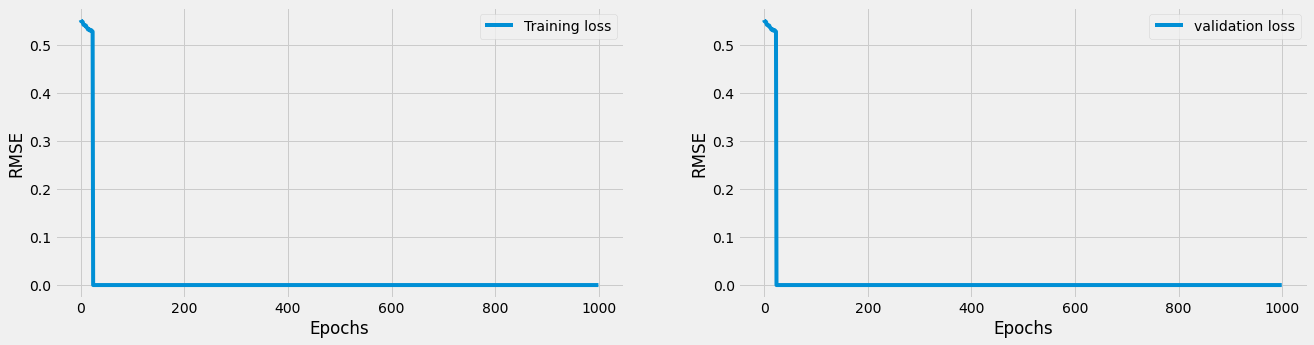

In [ ]:
plt.subplots(figsize=(20,5))
plt.subplot(1,2,1)
plt.ylabel("RMSE")
plt.xlabel("Epochs")
     
plt.plot(hist, label="Training loss")
plt.legend()

plt.subplot(1,2,2)     
plt.ylabel("RMSE")
plt.xlabel("Epochs")
plt.plot(hist_val, label="validation loss")
plt.legend()

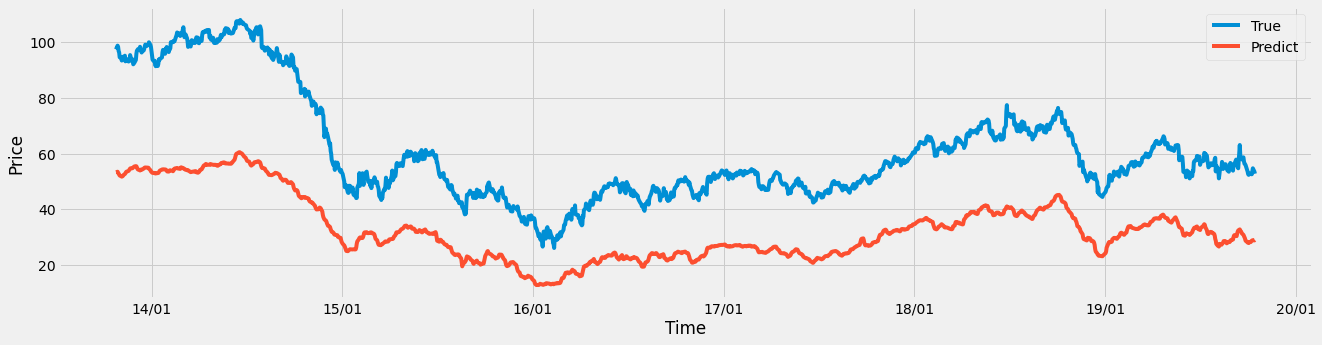

In [ ]:
# Training data 訓練結果

pred = model(x_train)
plt.subplots(figsize=(20,5))
plt.ylabel("Price")
plt.xlabel("Time")
pred = scaler1.inverse_transform(pred.detach().cpu().numpy()) #去除Tensor中的Cuda
pred_list = [] #pred to list
for i in pred:
  pred_list.append(i[0])

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%y/%m')) #設定橫軸格式
plt.plot(train_dates,train_true, label="True")
plt.plot(train_dates,pred_list, label="Predict")

plt.legend()

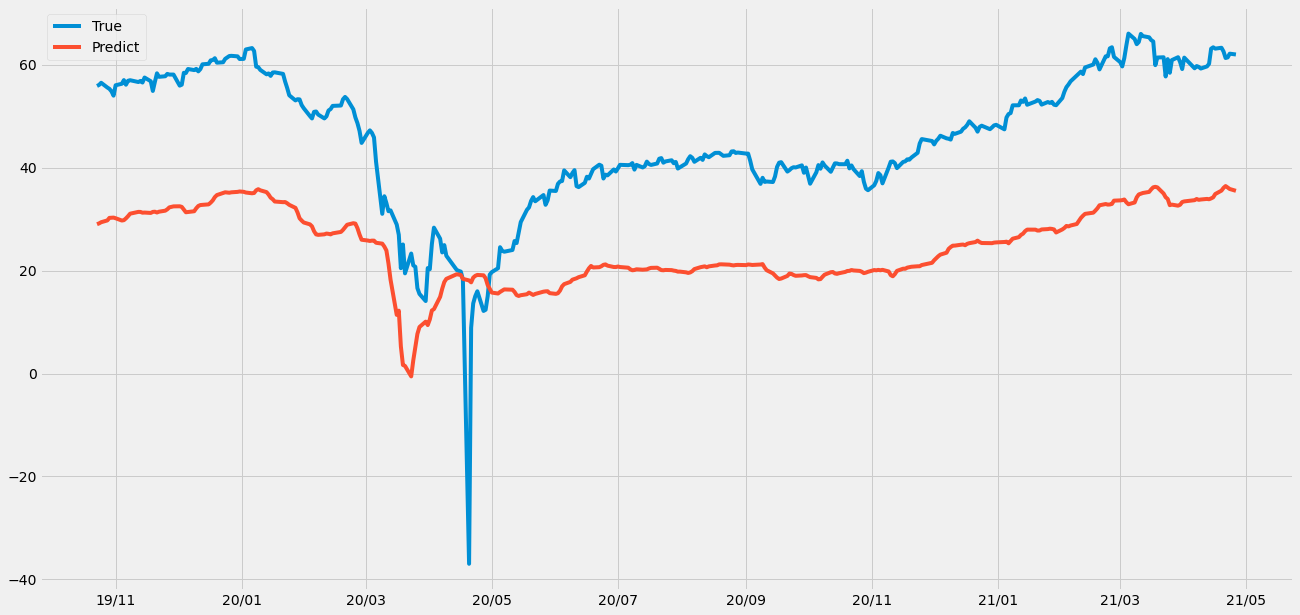

In [ ]:
# Testing data訓練結果
plt.subplots(figsize=(20,10))
pred = model(x_valid)
pred = scaler1.inverse_transform(pred.detach().cpu().numpy())
pred_list = [] #pred to list
for i in pred:
  pred_list.append(i[0])
  
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%y/%m'))
plt.plot(test_dates, test_true, label="True")
plt.plot(test_dates, pred_list, label="Predict")
plt.legend()

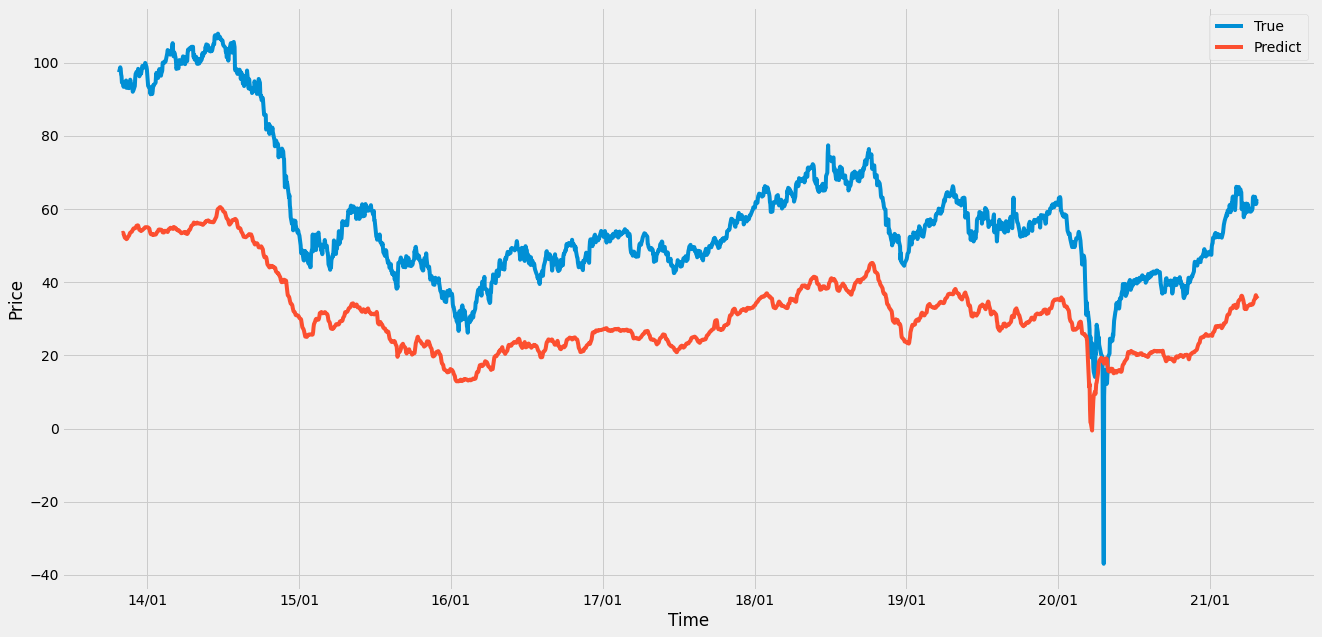

In [ ]:
# 全期訓練結果

plt.subplots(figsize=(20,10))
data = torch.tensor(data, dtype = torch.float)

pred = model(x_all.to(device))
plt.ylabel("Price")
plt.xlabel("Time")
pred = scaler1.inverse_transform(pred.detach().cpu().numpy())

pred_list = [] #pred to list
for i in pred:
  pred_list.append(i[0])

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%y/%m'))

plt.plot(dates, df_features1, label="True")

plt.plot(dates[look_back_windows:], pred_list,  label="Predict")

plt.legend()

# Petroleum Inventory Level: A Leading Indicator of Prices 

This ipynb proposes a long-run forecasting model of WTI spot price using US petroleum inventory level. 
- The inventory data used in the model is updated each wednesday 10:30 AM EST, resulting in a new forecasted value for each report. 
- Applying the forecasting model between January 2010 to date, and evaluates a forecasting model for the WTI spot price. I find that the model delivers persistent long-term performance. 
- The model is useful for those who are interested in forecasting future oil prices or for those who wish to understand and interpret historical price fluctuations.
- In order to test the predictive power of the model, I employ out-of-sample forecasting. The result suggests that the petroleum inventory level has been a leading indicator for the crude oil spot price for the last decade. 

**Theory**

Intuitively, there should be a negative relationship between the petroleum inventory level and the oil price. The
rationale is that a petroleum inventory change can be interpreted as the result of the imbalance between supply and
demand, and should therefore affect the spot price in an inverse manner. 

In practise, the relationship between the petroleum inventory
level and the oil price is, however, not directly obvious; as the petroleum inventory level is affected by seasonal movements
and a general trend that tends to mask the connection. The relative inventory level is an indicator that normalizes 
the petroleum inventory level for any deterministic time trend and seasonal variation in production, consumption and refinery 
utilization. 

The central concept is that if current inventories deviate from their normal level, according to inventory trend 
and seasonal swings, the market is in disequilibrium and prices should react accordingly. The relative inventory level, RIN, is defined as the deviation of the observed petroleum inventory level, IN, 
from a historically determined normal level, IN hat. A time dummy variable, D, is used to extract the seasonal effect from the observed inventory level. 

The observed inventories are de-seasonalized through the following regression. 

$$  ln{(IN_t)} = \alpha_o + \sum_{k=2}^{n}\beta_k D_k + \epsilon_t \tag{1} $$

$$ ln{\widehat{(IN_t)}} = \alpha_o + \sum_{k=2}^{n}\beta_k D_k \tag{2} $$

Once the dummy parameters are estimated, one can extract the seasonal influence of the inventory level, where the
resulting residuals will represent the relative inventory level.

$$ ln{(RIN_t)} = ln{(IN_t)} - ln{(\widehat{IN}_t)}  \tag{3} $$

In [ ]:
import os, sys, collections, re, json, io, base64
import pandas as pd
import numpy as np
import seaborn as sns; sns.set()
import matplotlib.pyplot as plt
import scipy
import statsmodels.formula.api as smapi
import statsmodels.tsa.stattools as ts
import warnings
import scipy
import IPython
import sklearn

warnings.filterwarnings('ignore')
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

from IPython.display import HTML
from pandas import Series
from IPython.display import display, Math, Latex
from IPython.external import mathjax
from scipy import stats
from datetime import datetime
from matplotlib import pyplot as plt
from scipy.stats.stats import pearsonr
from sklearn import svm
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import datasets
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.tsa.arima_model import ARIMA
from pandas import Series

plt.style.use('ggplot')
plt.rc("savefig", dpi=110)

In [ ]:
# EIA Inventory Data (df)
dfInventory = pd.read_excel('http://ir.eia.gov/wpsr/psw01.xls', "Data 1", index_col="Date", parse_dates=["Date"], skiprows=2)

# Historical Spot Price (df3)
dfSpot = pd.read_excel('https://www.eia.gov/dnav/pet/xls/PET_PRI_SPT_S1_W.xls', "Data 1", parse_dates=["Date"], index_col="Date", skiprows=[0,1])

# Intrada Spot Price (Df5)
dfIntraSpot = pd.read_excel('https://www.eia.gov/dnav/pet/xls/PET_PRI_SPT_S1_D.xls', "Data 1", parse_dates=["Date"], index_col="Date", skiprows=[0,1])

# Subset
dfInventory = dfInventory["2010":"2050"]
dfSpot = dfSpot["2010":"2050"]
dfIntraSpot = dfIntraSpot["2010":"2050"]

# Create seasonal dummies
dfDummies = pd.get_dummies(dfInventory.index.week)
dfDummies.index = dfInventory.index
dfInventory = pd.concat([dfInventory, dfDummies], axis= 1)                          
                          
# Rename cols
dfInventory_cols = ['crude_oil','crude_oil_no_spr','crude_in_spr','gasoline','reformulated_gasoline','conventional_gasoline','blending_gasoline','fuel_ethanol','jet_fuel','distillate', 'distillate_15ppm','distillate_500ppm','distillate_500+ppm','residual_oil','propane_propylene','other_oils','unfinished_oils','Inventory','crude_products_no_spr', 'W1','W2', 'W3', 'W4', 'W5', 'W6', 'W7','W8','W9' ,'W10' ,'W11' ,'W12' ,'W13', 'W14', 'W15', 'W16', 'W17', 'W18', 'W19', 'W20', 'W21', 'W22', 'W23', 'W24', 'W25', 'W26', 'W27', 'W28', 'W29', 'W30', 'W31', 'W32', 'W33', 'W34', 'W35', 'W36', 'W37', 'W38', 'W39', 'W40', 'W41', 'W42', 'W43', 'W44', 'W45', 'W46', 'W47', 'W48', 'W49', 'W50', 'W51', 'W52', 'W53']
dfInventory.columns = dfInventory_cols                          

dfSpot_cols = ['WTI', 'Brent']
dfSpot.columns = dfSpot_cols

dfIntraSpot_cols = ['WTI_daily', 'Brent_daily']
dfIntraSpot.columns = dfIntraSpot_cols 

In [ ]:
# Log Transformation
dfInventory['IP_log']= np.log(dfInventory.Inventory)

# Linear Regression
m1 = smapi.OLS.from_formula('IP_log ~ W1 +W2+ W3+ W4+ W5+ W6+ W7+ W8+ W9+ W10+ W11+ W12+ W13+ W14+ W15+ W16+ W17+ W18+ W19+ W20+ W21+ W22+ W23+ W24+ W25+ W26+ W27+ W28+ W29+ W30+ W31+ W32+ W33+ W34+ W35+ W36+ W37+ W38+ W39+ W40+ W41+ W42+ W43+ W44+ W45+ W46+ W47+ W48+ W49+ W50+ W51+ W52+ W53 -1', dfInventory).fit()

# Predict Residuals
dfInventory['RIN'] = m1.resid

# Concat Inventory Data with Weekly Spot Price 
df = pd.concat([dfInventory, dfSpot], axis= 1)

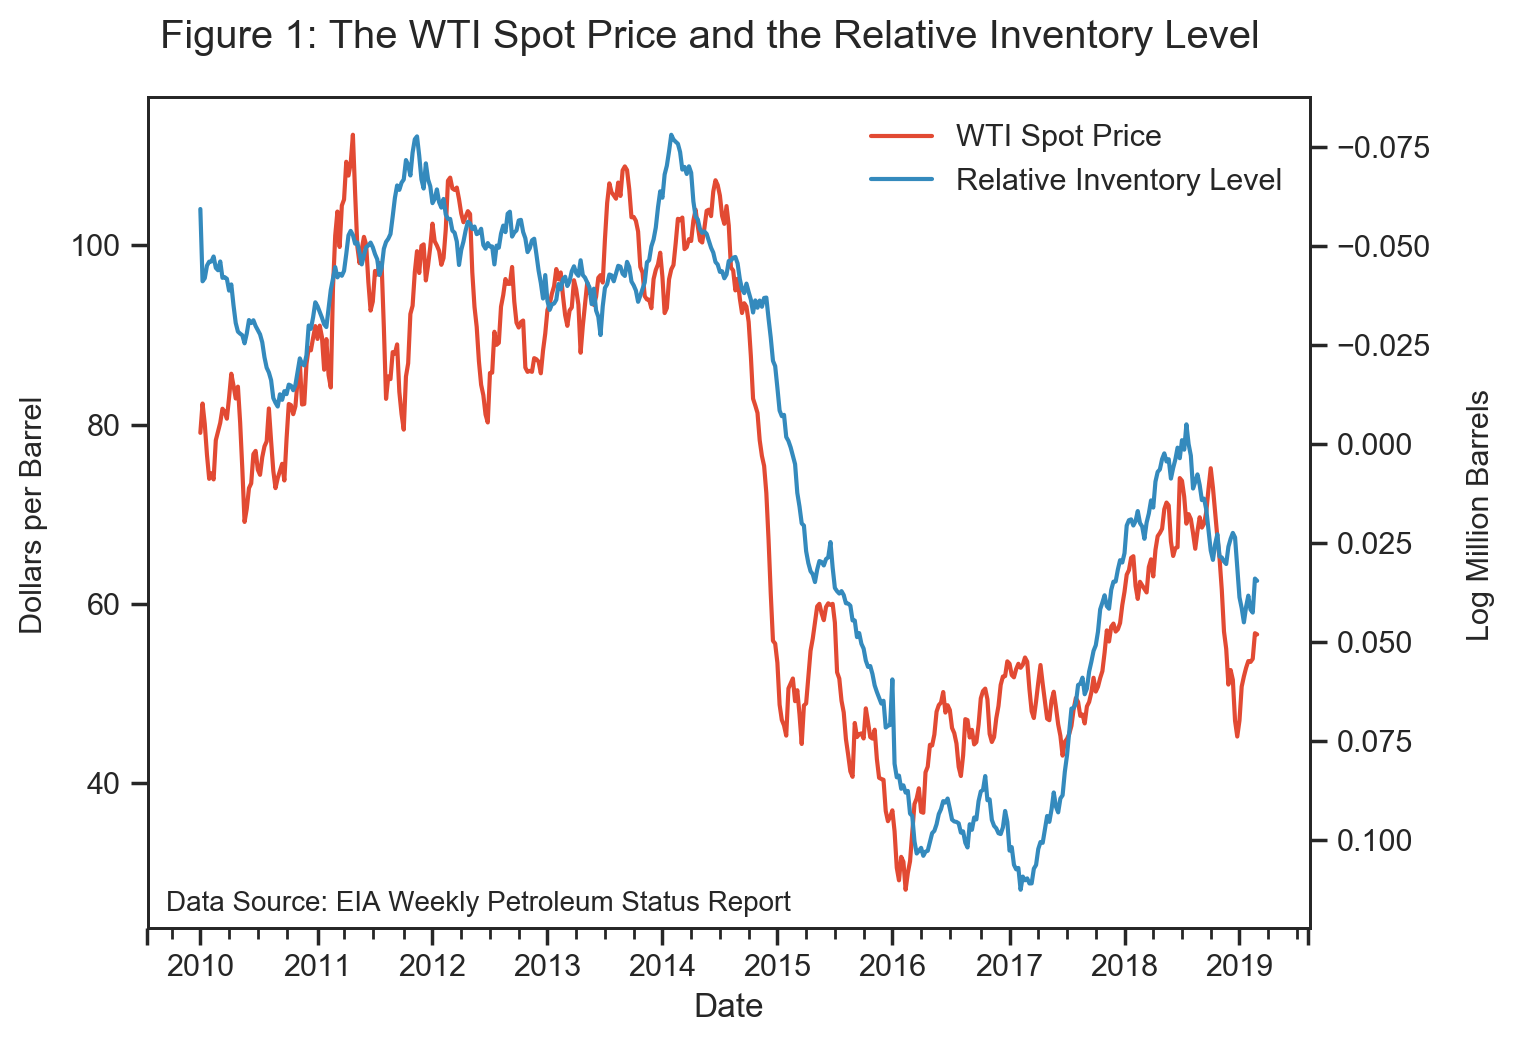

PearsonR Correlation Coefficient: -0.901 (WTI & RIN)


In [ ]:
sns.set_style("white")
sns.set_style("ticks")
fig= plt.figure(num=None, figsize=(7.5, 5.5), dpi=100)
ax1 = df['WTI'].plot(label='WTI Spot Price')
ax2 = df['RIN'].plot(secondary_y=True, label='Relative Inventory Level')
ax2 = plt.gca()
ax2.invert_yaxis()
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
plt.legend(h1+h2, l1+l2, loc=1, frameon=False)
plt.figtext(0.137, 0.14, "Data Source: EIA Weekly Petroleum Status Report", fontsize= 10)
plt.suptitle('Figure 1: The WTI Spot Price and the Relative Inventory Level', x=0.5, y=0.95, ha='center', fontsize='x-large')
plt.figtext(0.04, 0.5, 'Dollars per Barrel', va='center', rotation='vertical', fontsize=11)
plt.figtext(1.005, 0.5, 'Log Million Barrels', va='center', rotation='vertical', fontsize=11)
plt.style.use('ggplot')
plt.show()
corr = df['WTI'].corr(df['RIN'])
print('PearsonR Correlation Coefficient:',round(corr, 3),'(WTI & RIN)') 

In [ ]:
# Square relative inventory
df['RINsqr']= df['RIN']**2

# Predict forecast
m2 = smapi.OLS.from_formula('WTI ~ RIN + RINsqr', df).fit()
df['Forecast'] = m2.fittedvalues

# Create year variable to hue by year
df.reset_index(inplace=True)
df['Year'] = df['Date'].dt.year
df.set_index('Date', inplace=True)
df.ix[-1,'Year'] = 'Latest Week'

# Substitue "Latest Week" observation to intraday spot price
df.ix[-1,'WTI'] = dfIntraSpot.ix[-1,'WTI_daily']

##### Non-linearity Between Relative Inventory and the Spot Price  

A minimum operating level of petroleum inventory is essential to keep the North American supply system operating;
pipeline systems need a cushion level of inventory to keep the system running, road tankers and railcars need fuel to link 
the production sites, and terminals and refineries need a base level to operate. Due to the economy requiring a minimum 
operating level of petroleum inventories, the relationship between the inventory level and the spot price is intrinsically 
non-linear. That is, if the inventory level were to approach its minimum operating level, prices should
in theory react in a non-linear fashion (increase exponentially) to compensate for the risk associated with a stock out. Petroleum 
inventories can also be viewed as being limited due to infrastructure constraints. Once the inventory surplus breaches
logistical and spare storage capacity, oil prices should converge to marginal cost and force producers
to stop producing. U.S. shale wells can have a variable cost below 15 dollars a barrel, resulting in that their owners
will keep on producing even if spot prices are below the producers average cost.

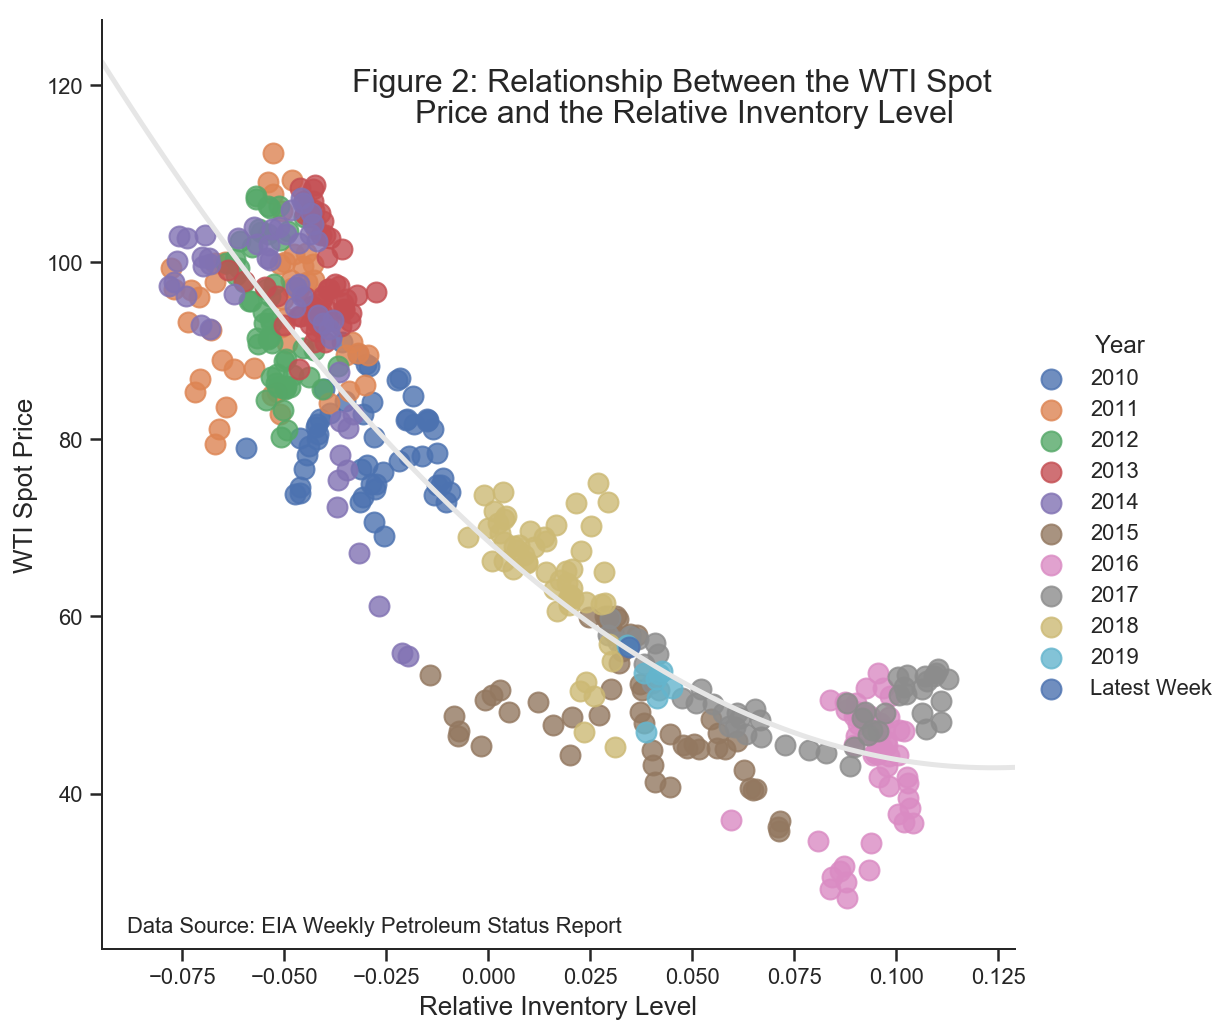

PearsonR Correlation Coefficient: 0.92 (WTI & Fitted line)
R2, Coefficient of Determination: 0.847


In [ ]:
sns.set_style("white")
sns.set_style("ticks")
plot1 = sns.lmplot(x="RIN", y="WTI", data=df, hue='Year', fit_reg=False,  
        
    height = 7.3, aspect = 1, palette="deep",
    order=2, ci=None,  scatter_kws={"s": 100});

plot1 = sns.regplot("RIN", "WTI", data=df, color=".9", scatter=False, order=2, ci=None, line_kws={"lw":2.5});

csfont = {'fontname':'Times New Roman'}

plt.figtext(0.12, 0.10, "Data Source: EIA Weekly Petroleum Status Report", fontsize= 11)
plt.figtext(0.30, 0.9, "Figure 2: Relationship Between the WTI Spot", fontsize= 16)
plt.figtext(0.35, 0.87, "Price and the Relative Inventory Level", fontsize= 16)
plt.xlabel("Relative Inventory Level", fontsize = 13)
plt.ylabel('WTI Spot Price', fontsize = 13)
plt.show()

corr = df['Forecast'].corr(df['WTI'])
r2 = corr * corr

print('PearsonR Correlation Coefficient:',round(corr, 3),'(WTI & Fitted line)')
print('R2, Coefficient of Determination:',round(r2, 3))
# plt.savefig('plot_name.png', dpi = 1000)

Figure 2 above, demonstrate the non-linear relationship between the WTI spot price and the relative inventory level. On 
the vertical axis, the WTI spot price is shown in U.S. dollars per barrel and on the horizontal axis, the U.S. relative
inventory level is shown in natural logarithmic scale. The fitted gray line is equivalent to the long-run forecasting model. The upper 
and lower bound of petroleum inventories - created by infrastructure constraints and the minimum operating level - contributes 
with a steeper curvature at the extreme points. In essence, the 
market recognize whether the prevailing storage level is sustainable or not and adjusts the WTI price accordingly. The price 
is thus the mechanism the market employs to secure adequate supply and to discourage the maintenance of surplus supply.

### Model  
In this section, I present the relative inventory model that is used to predict the oil price. The model rests on the notion that the price
of oil is determined by the equilibrium between supply and demand in the physical market. The purpose of the forecast is not to predict short-run changes in the spot, but
to separate the short-term noise from the long-run signal. When creating a short-run forecasting model, an ARIMA-model would be more appropriate. 

In equation 4, the relative inventory model is expressed as:

$$WTI_t = \alpha_o + \beta_1RIN_{t-1} + \beta_1{RIN^2}_{t-1} + \mu_t\tag{4}$$

where WTI is the average weekly WTI spot price at time t and RIN is the relative inventory level a period
before. A squared variable of the relative inventory level is added to capture the non-linear dynamic between oil prices and 
petroleum inventories.

### Data
A database covering petroleum inventory is a prerequisite for this work. The International Energy Agency (IEA)
and the U.S. Energy Information Administration (EIA) provides the most comprehensive data in terms of quality,
nations covered, consistency of reporting and detailed used. I will use the EIA Weekly Petroleum Status Report, as
the data is readily available online for anyone to reach. The EIA data set is published on a weekly basis, and covers
U.S. petroleum inventories by Petroleum Administration for Defense District (PADD). I chose to limit the
data to the United States, as I hypothesize that the U.S. inventory level has grown to be the most imperative region
in its predictive power of the WTI spot price. 

The Petroleum inventory level represent the amount of inventory of crude oil and petroleum products held in
inventory for future use. Inventories are accounted for on a national territory basis, within a country’s geographical
region and irrespective of ownership. Granted that the inventories are held on the national territory, it does not
matter whether the inventories are held onshore, offshore, at refineries or in pipelines. The inventory level is
measured by the EIA-813 Crude Oil Report, which requires companies that carry or store 1,000 barrels or
more to submit information regarding all domestic and foreign inventories held in custody and in transit thereto.
The petroleum inventory consists of crude oil, which represent the liquid that is extracted from the geological
formation, and petroleum products, which are produced from the processing of crude oil. Petroleum inventories
can further be divided into commercial inventories, which represent petroleum inventories held for commercial
purposes by U.S. firms, and strategic inventories, which represent petroleum inventories maintained by the Federal
Government. 

For the crude oil spot price, I use West Texas Intermediate (WTI), which together with Brent are considered the
world’s benchmark for crude oil prices. WTI is the crude oil specified for delivery to Cushing, Oklahoma under the
New York Mercantile Exchange (NYMEX) futures contract, which makes WTI the proper benchmark to compare
with U.S. petroleum inventories. 

### Empirical Results

In order to test the predictive power of the model, I employ out-of-sample forecasting. 
I split the dataset into 70/30%, with the first period being defined as in-sample and the later period being defined 
as out-of-sample.

In [ ]:
X = df[['RIN', 'RINsqr']]
y = df['WTI']

# In& Out-Of-Sample regression
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, shuffle=False) # random_state=0
# Shuffle = True (K-fold & LOOVC) is not always appropriate for time series as order of sequence is lost. 
# Shuffle is appropriate for models with IID data like ARIMA(p,d,q) 

# 1. Set up the model
model = LinearRegression()

# 2. Use fit
model.fit(X_train, y_train)

# 3. Check the accuracy score 
trainscore = model.score(X_train, y_train)

model.coef_ # Get the coefficients, beta

model.intercept_ # Get the intercept, c

print('In-Sample, Accuracy score:',round(trainscore, 3))

In-Sample, Accuracy score: 0.808


In [ ]:
# prediction in & out-of-sample
y_pred_test = model.predict(X_test) 
y_pred_train = model.predict(X_train) 

# Create dataframe
df_train_prediction = pd.DataFrame(y_pred_train)
df_test_prediction = pd.DataFrame(y_pred_test)

# Rename columns
df_train_prediction_cols = ['TrainForecast']
df_test_prediction_cols = ['TestForecast']

df_train_prediction.columns = df_train_prediction_cols
df_test_prediction.columns = df_test_prediction_cols

In [ ]:
ntrain = df_train_prediction.shape[0]
ntest = df_test_prediction.shape[0]

# Split data into train & test dataset
train = df.iloc[:ntrain]
test = df.iloc[ntrain:]

# Set index for graphing purpose
df_train_prediction.index = train.index
df_test_prediction.index = test.index

# Concat dataframe
train = pd.concat([df_train_prediction, train], axis= 1)
test = pd.concat([df_test_prediction, test], axis= 1)

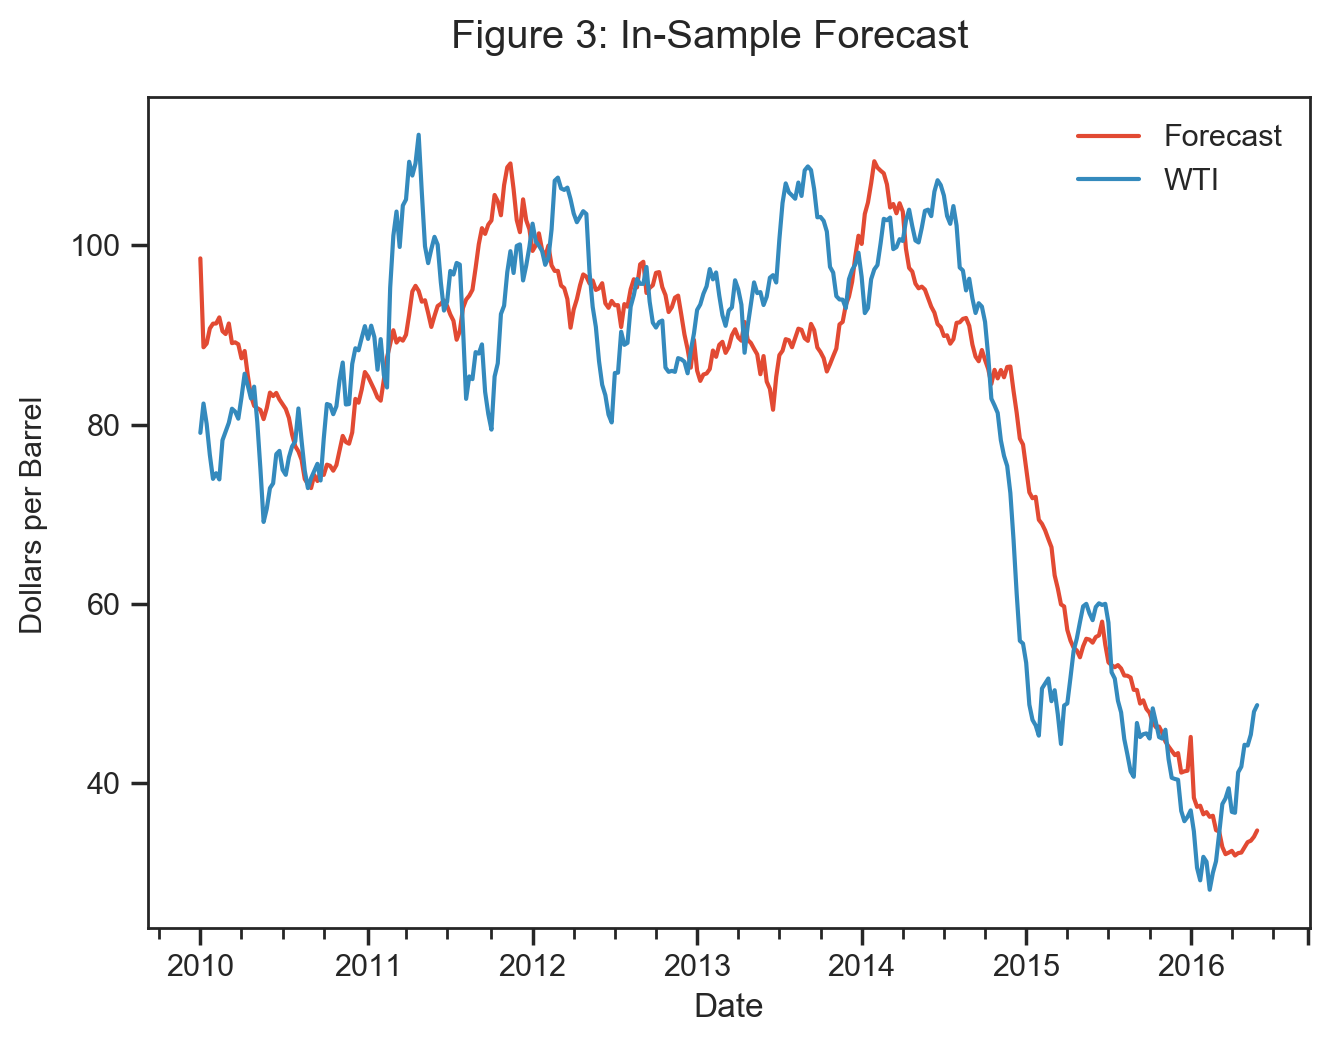

RMSE, Root Mean Square Error: 9.521
MSE, Mean Square Error: 90.658
PearsonR Correlation Coefficient: 0.899
R2, Coefficient of Determination: 0.808


In [ ]:
# In-Sample
sns.set_style("white")
sns.set_style("ticks")
fig= plt.figure(num=None, figsize=(7.5, 5.5), dpi=100)
plt.suptitle('Figure 3: In-Sample Forecast', x=0.5, y=0.95, ha='center', fontsize='x-large')
ax = train['TrainForecast'].plot(label='Forecast')
ax = train['WTI'].plot(label='WTI')
ax = plt.gca()
plt.figtext(0.04, 0.5, 'Dollars per Barrel', va='center', rotation='vertical', fontsize=11)
plt.legend(frameon=False)
plt.show()

# Measure differences between prediction & observed value
RMSEtrain = (((train['TrainForecast'] - train['WTI']) ** 2).mean() ** .5)
MSEtrain = ((train['TrainForecast'] - train['WTI']) ** 2).mean()
CORRtrain = train['TrainForecast'].corr(train['WTI'])
R2train = (train['TrainForecast'].corr(train['WTI'])**2)

print("RMSE, Root Mean Square Error:", round(RMSEtrain,3))
print("MSE, Mean Square Error:", round(MSEtrain,3))
print("PearsonR Correlation Coefficient:", round(CORRtrain,3))
print("R2, Coefficient of Determination:", round(R2train,3))

Figure 3 above demonstrates the long-run forecast and the spot WTI price for the in-sample period. 
On the vertical axis, the WTI spot price is shown in U.S. dollars per barrel.

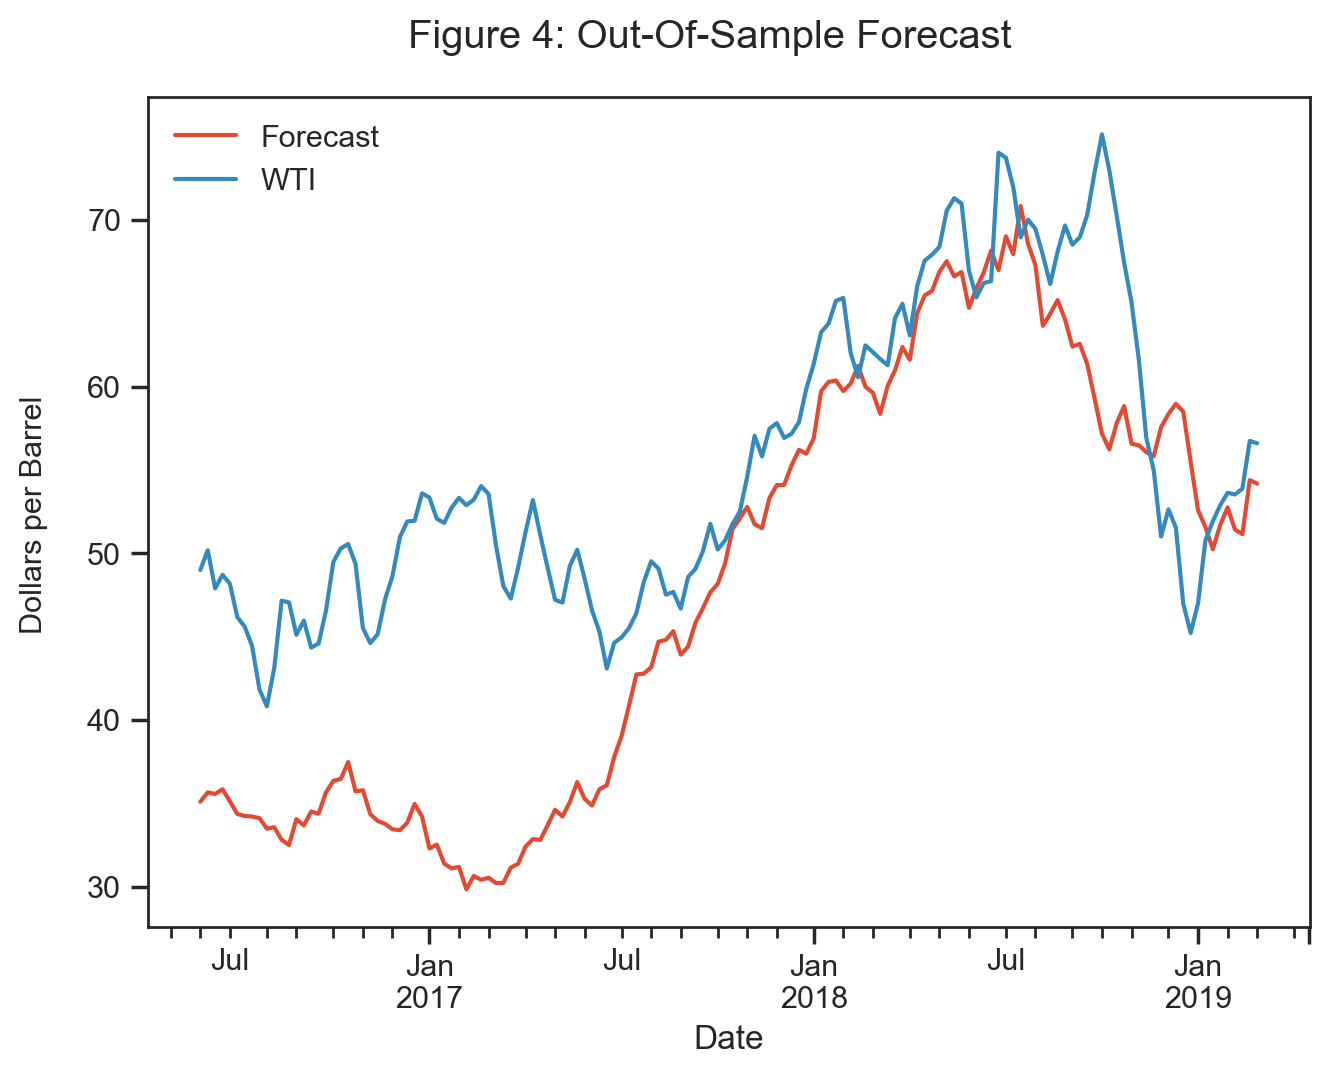

RMSE, Root Mean Square Error: 10.495
MSE, Mean Square Error: 110.135
PearsonR Correlation Coefficient: 0.833
R2, Coefficient of Determination: 0.694


In [ ]:
# Out-Of-Sample
sns.set_style("white")
sns.set_style("ticks")
fig= plt.figure(num=None, figsize=(7.5, 5.5), dpi=100)
plt.suptitle('Figure 4: Out-Of-Sample Forecast', x=0.5, y=0.95, ha='center', fontsize='x-large')
ax = test['TestForecast'].plot(label='Forecast')
ax = test['WTI'].plot(label='WTI')
ax = plt.gca()
plt.figtext(0.04, 0.5, 'Dollars per Barrel', va='center', rotation='vertical', fontsize=11)
plt.legend(frameon=False)
plt.show()

RMSEtest = (((test['TestForecast'] - test['WTI']) ** 2).mean() ** .5)
MSEtest = ((test['TestForecast'] - test['WTI']) ** 2).mean()
CORRtest = test['TestForecast'].corr(test['WTI'])
R2test = (test['TestForecast'].corr(test['WTI'])**2)

print("RMSE, Root Mean Square Error:", round(RMSEtest,3))
print("MSE, Mean Square Error:", round(MSEtest,3))
print("PearsonR Correlation Coefficient:", round(CORRtest,3))
print("R2, Coefficient of Determination:", round(R2test,3))

Figure 4 above illustrates the long-run forecast and the spot WTI price for the out-of-sample period. 
On the vertical axis, the WTI spot price is shown in U.S. dollars per barrel.

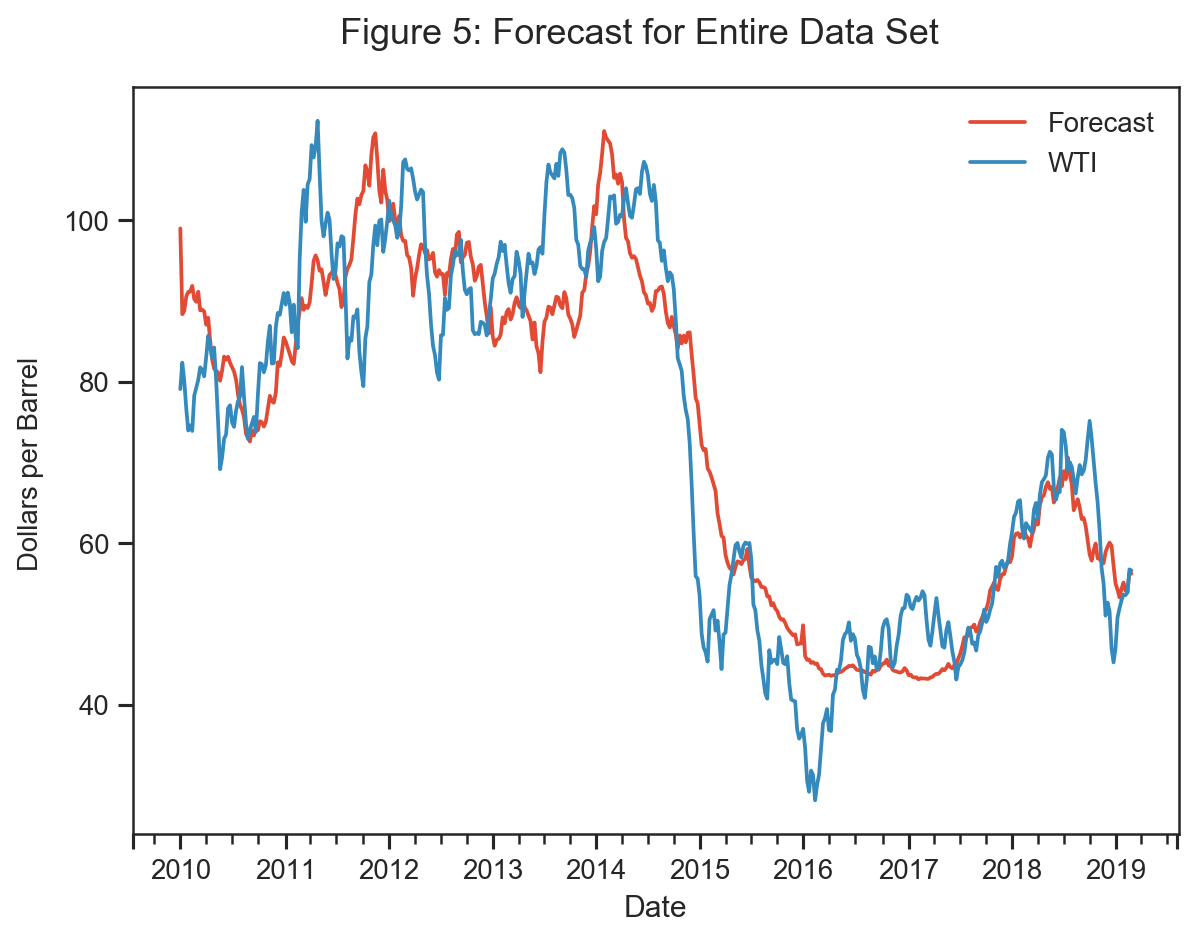

RMSE, Root Mean Square Error: 8.766
MSE, Mean Square Error: 76.841
PearsonR Correlation Coefficient: 0.92
R2, Coefficient of Determination: 0.847


In [ ]:
fig= plt.figure(num=None, figsize=(7.5, 5.5), dpi=90)
sns.set_style("ticks")
plt.suptitle('Figure 5: Forecast for Entire Data Set', x=0.5, y=0.95, ha='center', fontsize='x-large')
ax1 = df['Forecast'].plot(label='Forecast')
ax1 = df['WTI'].plot(secondary_y=False, label='WTI')
ax1 = plt.gca()
plt.figtext(0.04, 0.5, 'Dollars per Barrel', va='center', rotation='vertical', fontsize=11)
plt.legend(frameon=False)
sns.set_style("white")
plt.show()

df['lag_wti']= df['WTI'].shift(1) 

RMSE = (((df['Forecast'] - df['WTI']) ** 2).mean() ** .5)
MSE = ((df['Forecast'] - df['WTI']) ** 2).mean()
CORR = df['Forecast'].corr(df['WTI'])
R2 = (df['Forecast'].corr(df['WTI'])**2)

print("RMSE, Root Mean Square Error:", round(RMSE,3))
print("MSE, Mean Square Error:", round(MSE,3))
print("PearsonR Correlation Coefficient:", round(CORR,3))
print("R2, Coefficient of Determination:", round(R2,3))

Figure 5 above illustrates the long-run forecast and the spot WTI price for the entire sample. 
On the vertical axis, the WTI spot price is shown in U.S. dollars per barrel.

In [ ]:
print(round(df[['WTI', 'Forecast', 'RIN', 'Inventory']].tail(5),3))  

print("")

print("The table above demonstrates the five latest predicted values generated by the long-run forecast.")
print("At the moment, the long-run forecast suggests a fair value of", round(df.ix[-1,'Forecast'], 2), "dollars per barrel for the WTI spot price.") 

if df.ix[-1,'Forecast'] > df.ix[-1,'WTI']:
     print("The forecasted value is", round((df.ix[-1,'Forecast'] - df.ix[-1,'WTI']),2), "dollars per barrel above the average weekly WTI spot price")    
else:
     print("The forecasted value is", round((df.ix[-1,'WTI'] - df.ix[-1,'Forecast']),2), "dollars per barrel below the average weekly WTI spot price.")
     

              WTI  Forecast    RIN  Inventory
Date                                         
2019-02-01  53.63    55.108  0.038  1908119.0
2019-02-08  53.53    54.119  0.042  1914651.0
2019-02-15  53.88    53.914  0.043  1912165.0
2019-02-22  56.74    56.369  0.034  1894292.0
2019-03-01  56.60    56.201  0.035  1893831.0

The table above demonstrates the five latest predicted values generated by the long-run forecast.
At the moment, the long-run forecast suggests a fair value of 56.2 dollars per barrel for the WTI spot price.
The forecasted value is 0.4 dollars per barrel below the average weekly WTI spot price.


### Appendix

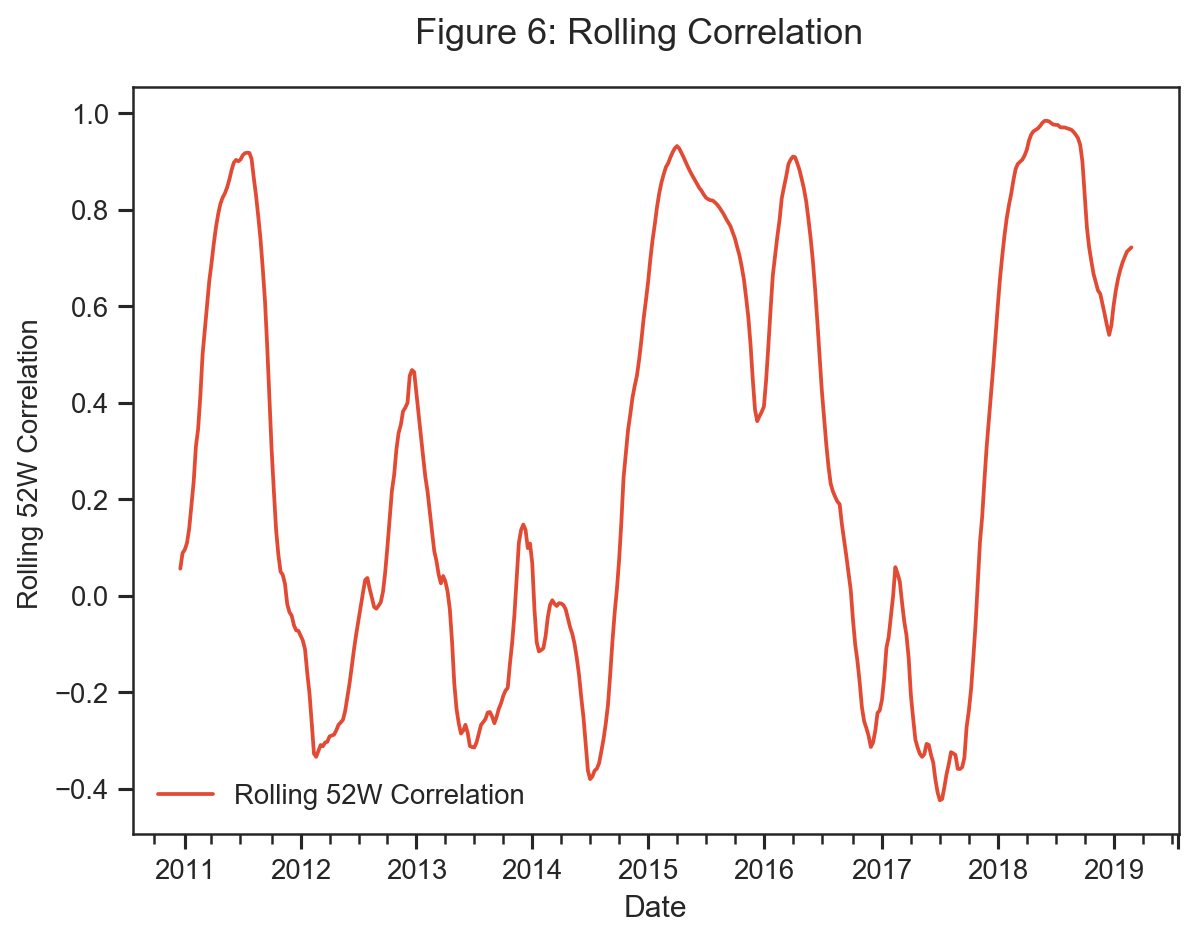

In [ ]:
df['corr'] = df['WTI'].rolling(window=52).corr(df['Forecast'])
df['rollingmean'] = pd.Series.rolling(df['Forecast'], window=20).mean()
df['STD'] = pd.Series.rolling(df['WTI'], window=52).std()

fig= plt.figure(num=None, figsize=(7.5, 5.5), dpi=90)
sns.set_style("ticks")
plt.suptitle('Figure 6: Rolling Correlation', x=0.5, y=0.95, ha='center', fontsize='x-large')
ax1 = df['corr'].plot(label='Rolling 52W Correlation')
# ax2 = df20['STD'].plot(secondary_y=True, label='WTI Standard Deviation')
plt.figtext(0.04, 0.5, 'Rolling 52W Correlation', va='center', rotation='vertical', fontsize=11)
# plt.figtext(1.005, 0.5, 'Standard Deviation', va='center', rotation='vertical', fontsize=11)
ax2 = plt.gca()

#h1, l1 = ax1.get_legend_handles_labels()
#h2, l2 = ax2.get_legend_handles_labels()
plt.legend(loc=3, frameon=False)
#plt.legend(h1+h2, l1+l2, loc=2, frameon=False)
plt.show()